# Sistemas de recomendación

**Caso Last.fm | Plataforma regional de streaming musical**

---

## Resumen para lectura rápida

**Pregunta del cliente:** ¿qué motor de recomendación desplegar en el módulo "Descubre", y bajo qué condiciones?

**Respuesta:** desplegar **reglas de asociación ordenadas por lift** como motor principal, con **SVD de 20 factores como respaldo**, en forma de piloto A/B medido y no como lanzamiento definitivo.

**Las tres cifras que sostienen la decisión:**

| | |
|---|---|
| Recomendar por popularidad cubre | **0,18% del catálogo** (31 artistas de 17.632) |
| El motor recomendado deja en el Top 100 | **10% de lo que sugiere**, frente al 69% del SVD |
| Ningún motor evaluado supera | **3% de cobertura de catálogo** |

**El trade-off aceptado:** se renuncia a precisión medible (recall 0,0713 contra 0,1653 del SVD) a cambio de descubrimiento, porque la métrica disponible premia recomendar lo que el usuario ya escucharía de todos modos.

---

## Guía de lectura


| Paso | Contenido | Hallazgo principal |
|---|---|---|
| **1** | Exploración y problema de negocio | El 60,57% del catálogo tiene un solo oyente |
| **2** | Preparación y decisiones transversales | Matriz 99,72% vacía; se elige escala logarítmica |
| **3** | Línea base: popularidad | Cubre 31 artistas; 53,3% de solape entre usuarios |
| **4** | Vecindad: similitud de coseno | El sesgo a lo masivo es estructural, no de calibración |
| **5** | Factorización latente: SVD | El criterio de varianza explicada no aplica; el óptimo predictivo es 20 factores |
| **6** | Reglas de asociación: Apriori | Confianza y lift ordenan reglas opuestas |
| **7** | Comparación, ranking y recomendación | El motor que mejor descubre no es el que mejor acierta |
| **Anexo** | Cifras consolidadas | Todo lo citable, en un solo lugar |

---


# Paso 1. Exploración de los datos y el problema de negocio

## 1.1. Carga de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix, save_npz

## 1.2. Carga de bases

In [2]:
# Configuración de estilo gráfico
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

#carga de bases de datos
df_user_artists = pd.read_csv('data/user_artists.txt', sep='\t')
df_artists = pd.read_csv('data/artists.txt', sep='\t')

In [3]:
# Renombrado
df_artists = df_artists.rename(columns={
    'id': 'artist_id',
    'name': 'artist_name',
    'url': 'artist_url',
    'pictureURL': 'picture_url'
})

df_artists.head()

,artist_id,artist_name,artist_url,picture_url
0,1,MALICE MIZER,http://www.last.fm/music/MALICE+MIZER,http://userserve-ak.last.fm/serve/252/10808.jpg
1,2,Diary of Dreams,http://www.last.fm/music/Diary+of+Dreams,http://userserve-ak.last.fm/serve/252/3052066.jpg
2,3,Carpathian Forest,http://www.last.fm/music/Carpathian+Forest,http://userserve-ak.last.fm/serve/252/40222717...
3,4,Moi dix Mois,http://www.last.fm/music/Moi+dix+Mois,http://userserve-ak.last.fm/serve/252/54697835...
4,5,Bella Morte,http://www.last.fm/music/Bella+Morte,http://userserve-ak.last.fm/serve/252/14789013...


In [4]:
# Renombrado
df_user_artists = df_user_artists.rename(columns={
    'userID': 'user_id',
    'artistID': 'artist_id',
    'weight': 'plays'
})

df_user_artists.head()

,user_id,artist_id,plays
0,2,51,13883
1,2,52,11690
2,2,53,11351
3,2,54,10300
4,2,55,8983


In [5]:
# Fusión de conjuntos de datos
df_interactions = pd.merge(
    df_user_artists,
    df_artists[['artist_id', 'artist_name']],
    on='artist_id',
    how='left'
)

df_interactions.head()

,user_id,artist_id,plays,artist_name
0,2,51,13883,Duran Duran
1,2,52,11690,Morcheeba
2,2,53,11351,Air
3,2,54,10300,Hooverphonic
4,2,55,8983,Kylie Minogue


**Decisión de cambio de nombres a las columnas**

Se estandarizó la nomenclatura de las bases de datos user_artists.dat y artists.dat utilizando el formato snake_case. Específicamente, se redefinieron las columnas userID como user_id, artistID como artist_id, weight como plays y name como artist_name. Esta homogenización es fundamental para evitar errores en las uniones de tablas (joins) y otorgar mayor claridad semántica al análisis: al renombrar la variable weight por plays, se refiere a que el dato representa la cantidad de reproducciones implícitas por usuario.

## 1.3. Descripción del dataset

In [6]:
# Métricas generales del dataset

n_users = df_interactions['user_id'].nunique()
n_artists = df_interactions['artist_id'].nunique()
n_interactions = len(df_interactions)

print("=== MÉTRICAS GENERALES ===")
print(f"Número de usuarios únicos: {n_users:,}")
print(f"Número de artistas únicos: {n_artists:,}")
print(f"Número de pares (usuario-artista) observados: {n_interactions:,}")

=== MÉTRICAS GENERALES ===
Número de usuarios únicos: 1,892
Número de artistas únicos: 17,632
Número de pares (usuario-artista) observados: 92,834


**¿Cuántos usuarios y cuántos artistas hay en la base? ¿Cuántos pares usuario-artista se observan?**

* Usuarios únicos (1.892): Representa el total de personas registradas en la
plataforma que registraron actividad de consumo de música.

* Artistas únicos (17.632): Es la cantidad total de músicos, bandas o creadores disponibles en el catálogo activo de la base de datos.

* Pares usuario-artista (92.834): Indica el número total de interacciones registradas, donde cada par representa a un usuario que ha escuchado a un artista específico al menos una vez.

In [7]:
# Distribución del consumo por artista (Unweighted vs Weighted)
# Ranking Sin Ponderar (Unweighted): Ocurrencia / número de usuarios únicos por artista

unweighted_pop = (
    df_interactions.groupby(['artist_id', 'artist_name'])['user_id']
    .nunique()
    .reset_index(name='user_count')
    .sort_values(by='user_count', ascending=False)
)

In [8]:
# Ranking Ponderado (Weighted): Suma total de reproducciones por artista

weighted_pop = (
    df_interactions.groupby(['artist_id', 'artist_name'])['plays']
    .sum()
    .reset_index(name='total_plays')
    .sort_values(by='total_plays', ascending=False)
)

In [9]:
# Comparación de Top 10

top10_unweighted = unweighted_pop.head(10).reset_index(drop=True)
top10_weighted = weighted_pop.head(10).reset_index(drop=True)

print("\n=== TOP 10 ARTISTAS: SIN PONDERAR (NÚMERO DE USUARIOS) ===")
print(top10_unweighted[['artist_id', 'artist_name', 'user_count']])

print("\n=== TOP 10 ARTISTAS: PONDERADO (TOTAL DE REPRODUCCIONES) ===")
print(top10_weighted[['artist_id', 'artist_name', 'total_plays']])


=== TOP 10 ARTISTAS: SIN PONDERAR (NÚMERO DE USUARIOS) ===
   artist_id         artist_name  user_count
0         89           Lady Gaga         611
1        289      Britney Spears         522
2        288             Rihanna         484
3        227         The Beatles         480
4        300          Katy Perry         473
5         67             Madonna         429
6        333       Avril Lavigne         417
7        292  Christina Aguilera         407
8        190                Muse         400
9        498            Paramore         399

=== TOP 10 ARTISTAS: PONDERADO (TOTAL DE REPRODUCCIONES) ===
   artist_id         artist_name  total_plays
0        289      Britney Spears      2393140
1         72        Depeche Mode      1301308
2         89           Lady Gaga      1291387
3        292  Christina Aguilera      1058405
4        498            Paramore       963449
5         67             Madonna       921198
6        288             Rihanna       905423
7        701   

**¿Cuál es la distribución del consumo por artista? Calcúlenla de dos formas: sin ponderar, es decir contando cuántos usuarios distintos escuchan a cada artista, y ponderando por el número de reproducciones.
¿Qué diferencias encuentran entre ambas?
¿Qué artistas cambian de posición y por qué?
¿Qué les dice esa comparación sobre qué significa ser “popular” en esta plataforma?**


* Popularidad sin ponderar: Liderado por Lady Gaga (611 usuarios) y Britney Spears (522 usuarios). Mide la capacidad de un artista para llegar a la mayor cantidad de oyentes distintos (amplitud de audiencia).  

* Popularidad ponderada: Liderado por Britney Spears (2.393.140 reproducciones) y Depeche Mode (1.301.308 reproducciones). Refleja el volumen masivo de escucha acumulado, impulsado por la fidelidad o frecuencia de consumo de los usuarios.  

* Diferencias clave entre rankings:
  1. Depeche Mode (ID 72) y Shakira (ID 701) no entran en el Top 10 de alcance, pero escalan a los puestos #2 y #8 en reproducciones totales por tener una base de oyentes muy intensiva (heavy listeners).  
  
  2. Lady Gaga cae del puesto #1 en alcance al #3 en reproducciones, mientras que Britney Spears hace el camino inverso, pasando del #2 al #1 con un volumen de reproducciones que casi duplica a sus seguidores más cercanos.  
  
  3. Artistas como The Beatles (ID 227) y Katy Perry (ID 300) muestran gran alcance horizontal (puestos #4 y #5 en usuarios), pero menor intensidad de consumo individual en comparación con el género pop/dance dominante en el Top ponderado.

In [10]:
# Catálogo de nicho y artistas escuchados por un solo usuario

artist_listeners = df_interactions.groupby('artist_id')['user_id'].nunique()
single_user_artists_count = (artist_listeners == 1).sum()
single_user_proportion = (single_user_artists_count / n_artists) * 100

print("\n=== ARTISTAS CON UN SOLO OYENTE ===")
print(f"Artistas escuchados por 1 solo usuario: {single_user_artists_count:,}")
print(f"Proporción del catálogo: {single_user_proportion:.2f}%")


=== ARTISTAS CON UN SOLO OYENTE ===
Artistas escuchados por 1 solo usuario: 10,679
Proporción del catálogo: 60.57%


**¿Cuántos artistas son escuchados por un solo usuario? ¿Qué proporción del catálogo representan? Si el cliente quiere hacer visible su catálogo, ¿qué implica esta cifra?**

Artistas escuchados por un solo usuario y su impacto

* Cantidad de artistas: 10.679 artistas en la base de datos son escuchados por un único usuario.

* Proporción del catálogo: Representan el 60,57% del catálogo total.

Implicaciones para el objetivo del cliente (Visibilidad del catálogo)

* Limitación del filtrado colaborativo: El filtrado colaborativo tradicional (User-Based o Item-Based) no puede recomendar más del 60% del catálogo. Al no existir superposición (overlap) entre usuarios para estos artistas, el algoritmo es incapaz de encontrar patrones de similitud.

* Problema del "Cold-Start" de ítems: Más de la mitad de los artistas están atrapados en la cola larga (Long Tail). Para visibilizarlos, el sistema requiere métodos basados en contenido (género, etiquetas, características de audio) o algoritmos híbridos.

* Riesgo de sesgo de popularidad: Si no se aplican técnicas de exploración, re-ranking o diversidad en el motor de recomendaciones, el sistema tenderá a sugerir únicamente el Top 10% de artistas más populares, dejando a la mayoría del catálogo completamente invisible.


=== PERFIL DE CONSUMO DEL USUARIO 8 (TOP 10 ARTISTAS) ===
   artist_id     artist_name  plays  relative_plays
0        334       No Angels   6291       17.340610
1        335           Sandy   2396        6.604372
2        289  Britney Spears   2258        6.223986
3        336  Vanessa Petruo   1735        4.782381
4        295         Beyoncé   1425        3.927892
5        337       Alexander   1407        3.878277
6        296       Sugababes   1039        2.863916
7        338     Queensberry    963        2.654428
8         89       Lady Gaga    921        2.538659
9        339    Fady Maalouf    819        2.257504


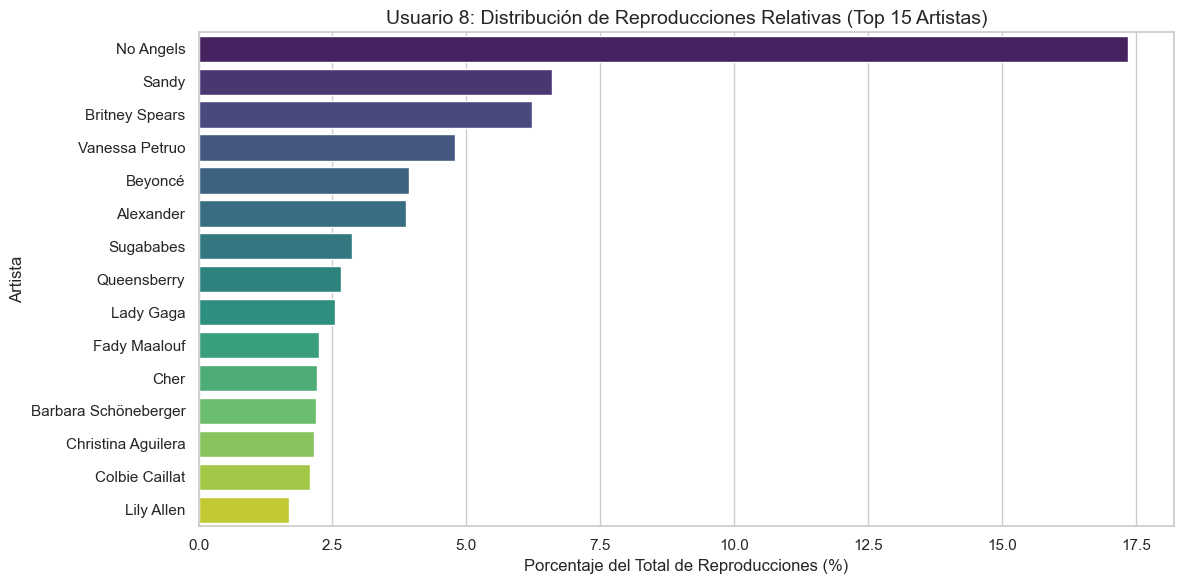

In [11]:
# Análisis del Usuario Ilustrativo (userID == 8)

user8_data = df_interactions[df_interactions['user_id'] == 8].copy()

# Cálculo de reproducciones relativas (%)
total_user8_plays = user8_data['plays'].sum()
user8_data['relative_plays'] = (user8_data['plays'] / total_user8_plays) * 100
user8_data = user8_data.sort_values(by='plays', ascending=False).reset_index(drop=True)

print("\n=== PERFIL DE CONSUMO DEL USUARIO 8 (TOP 10 ARTISTAS) ===")
print(user8_data[['artist_id', 'artist_name', 'plays', 'relative_plays']].head(10))

# Visualización del consumo del Usuario 8
plt.figure(figsize=(12, 6))
sns.barplot(
    data=user8_data.head(15),
    x='relative_plays',
    y='artist_name',
    hue='artist_name',
    palette='viridis',
    legend=False
)
plt.title('Usuario 8: Distribución de Reproducciones Relativas (Top 15 Artistas)', fontsize=14)
plt.xlabel('Porcentaje del Total de Reproducciones (%)', fontsize=12)
plt.ylabel('Artista', fontsize=12)
plt.tight_layout()
plt.show()

**Para el usuario 8 (userID==8), examinen su distribución de reproducciones relativas. Presenten los resultados en tablas y gráficas. ¿Qué patrón encuentran entre los artistas que escucha y las veces que los reproduce? ¿Qué se puede decir de sus preferencias?**

Patrón entre artistas y reproducciones

* Sesgo de concentración (Ley de Potencias): Existe una fuerte asimetría en su consumo. Su artista favorito (No Angels) concentra casi el 17,3% de todas sus reproducciones, triplicando al segundo lugar (Sandy, 6,6%).

* Caída rápida del volumen: El Top 3 de artistas acumula más del 30% del tiempo total de escucha del usuario, mientras que del puesto 10 en adelante cada artista representa menos del 2% del total.

Análisis de sus preferencias

* Coherencia aparente de género (Pop / Dance-Pop): los nombres sugieren una preferencia por pop comercial, girl bands y pop europeo (No Angels, Queensberry, Sugababes, Britney Spears, Lady Gaga). **Conviene señalar que esta lectura es una inferencia a partir de los nombres de los artistas, no un resultado de los datos**: la base no contiene etiquetas de género musical, así que ninguna de las dos bases permite verificarla. Se menciona como hipótesis descriptiva, no como hallazgo.

* Perfil de escucha: Combina un interés masivo por súper estrellas globales con una profunda lealtad hacia artistas locales/de nicho dentro de ese mismo género musical.

**El módulo “Descubre” debe sugerir artistas nuevos y relevantes. A la luz de la distribución del consumo que acaban de observar, ¿qué tan fácil o difícil parece ese objetivo?**

El objetivo resulta complicado por las siguientes razones:

* Sesgo de popularidad: El consumo se concentra fuertemente en pocos artistas masivos, por lo que los algoritmos tienden a recomendar siempre lo mismo en lugar de contenido nuevo.

* Pared del 60% del catálogo: Con 10.679 artistas que solo tienen 1 oyente, el filtrado colaborativo tradicional es incapaz de encontrar similitudes para recomendarlos.

* Evaluación engañosa: Como el historial de cada usuario está limitado a 50 artistas, un buen descubrimiento no registrado se evaluará erróneamente como un fallo en las métricas.

# Paso 2. Preparación de los datos: qué significa “similar”

## 2.1. Construcción de matriz usuario-artista

In [12]:
# Construcción de la Matriz Dispersa Usuario-Artista

# Mapeo de IDs contiguos para indexación matricial
user_ids = df_user_artists['user_id'].astype('category').cat.codes
artist_ids = df_user_artists['artist_id'].astype('category').cat.codes

n_users = user_ids.nunique()
n_artists = artist_ids.nunique()
n_interactions = len(df_user_artists)

# Matriz cruda en formato CSR
matrix_raw = csr_matrix(
    (df_user_artists['plays'], (user_ids, artist_ids)),
    shape=(n_users, n_artists),
    dtype=np.float32
)

# Cálculo de dispersión (Sparsity)
total_cells = n_users * n_artists
sparsity = (1.0 - (n_interactions / total_cells)) * 100

print("=== DIMENSIONES Y DISPERSIÓN DE LA MATRIZ ===")
print(f"Dimensiones de la matriz: {n_users} usuarios x {n_artists} artistas")
print(f"Celdas totales: {total_cells:,}")
print(f"Interacciones observadas: {n_interactions:,}")
print(f"Nivel de dispersión (Sparsity): {sparsity:.4f}%\n")

=== DIMENSIONES Y DISPERSIÓN DE LA MATRIZ ===
Dimensiones de la matriz: 1892 usuarios x 17632 artistas
Celdas totales: 33,359,744
Interacciones observadas: 92,834
Nivel de dispersión (Sparsity): 99.7217%



* Dimensiones de la matriz: Registra 1.892 usuarios y 17.632 artistas, lo que genera un espacio total de 33.359.744 celdas posibles.

* Interacciones observadas: Solo existen 92.834 pares con actividad registrada.

* Nivel de dispersión (sparsity): Alcanza un 99,72%, lo que significa que el 99,72% de la matriz está compuesto por celdas vacías (datos no observados o truncados).

## 2.2. Transformaciones de Representación del Consumo

In [13]:
# Transformaciones de Representación del Consumo


# Transformación Logarítmica: log(1 + plays)
df_user_artists['plays_log'] = np.log1p(df_user_artists['plays'])


# Normalización Min-Max por Usuario [0, 1]
user_max_plays = df_user_artists.groupby('user_id')['plays'].transform('max')
user_min_plays = df_user_artists.groupby('user_id')['plays'].transform('min')

df_user_artists['plays_norm'] = np.where(
    user_max_plays > user_min_plays,
    (df_user_artists['plays'] - user_min_plays) / (user_max_plays - user_min_plays),
    1.0
)


# Versión Binarizada
df_user_artists['plays_binary'] = 1


# Matriz dispersa final (Selección con transformación logarítmica)
matrix_log = csr_matrix(
    (df_user_artists['plays_log'], (user_ids, artist_ids)),
    shape=(n_users, n_artists),
    dtype=np.float32
)

save_npz('matrix_user_artists_log.npz', matrix_log)
print("Matriz dispersa con transformación logarítmica guardada exitosamente.\n")

Matriz dispersa con transformación logarítmica guardada exitosamente.



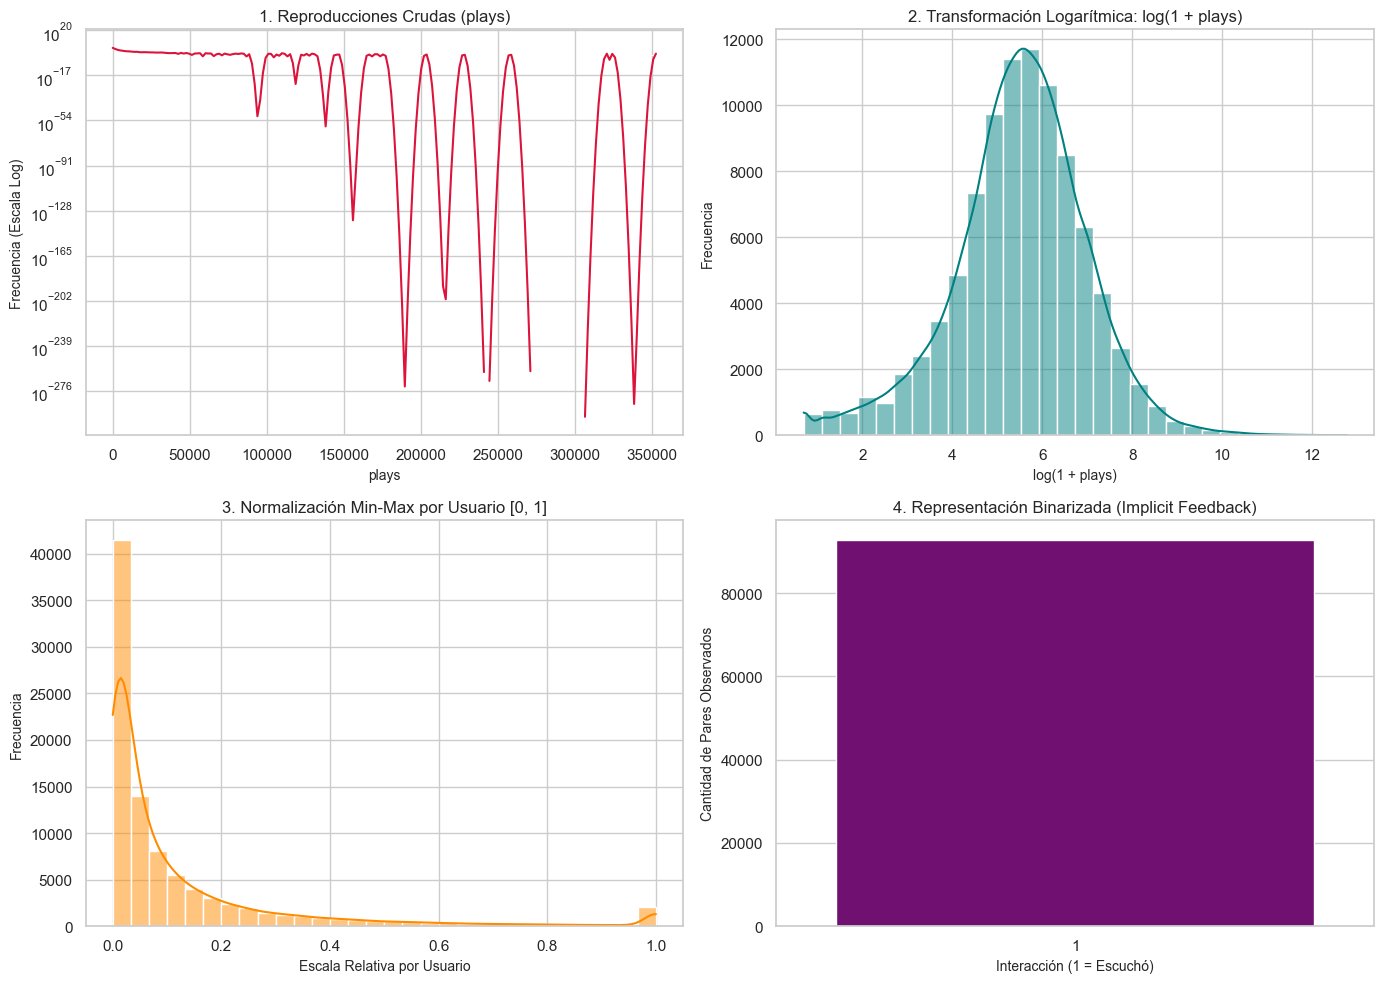

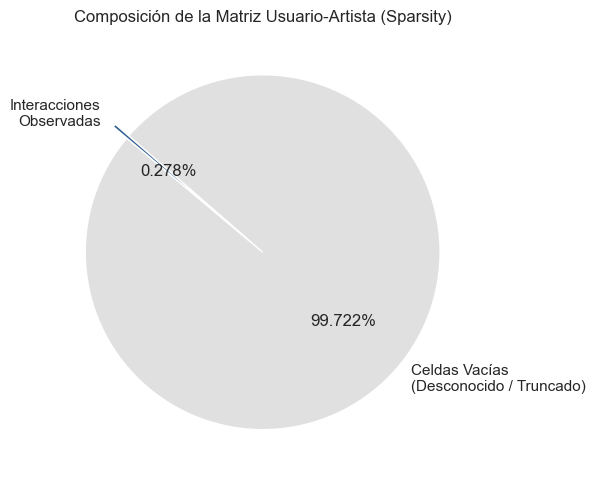

In [14]:
# Visualización Gráfica Comparativa (4 Representaciones de Consumo)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Reproducciones Crudas (Escala Log en Y)
sns.histplot(
    df_user_artists['plays'],
    bins=50,
    kde=True,
    ax=axes[0, 0],
    color='crimson',
    log_scale=(False, True)
)
axes[0, 0].set_title('1. Reproducciones Crudas (plays)', fontsize=12)
axes[0, 0].set_xlabel('plays', fontsize=10)
axes[0, 0].set_ylabel('Frecuencia (Escala Log)', fontsize=10)

# 2. Transformación Logarítmica
sns.histplot(
    df_user_artists['plays_log'],
    bins=30,
    kde=True,
    ax=axes[0, 1],
    color='teal'
)
axes[0, 1].set_title('2. Transformación Logarítmica: log(1 + plays)', fontsize=12)
axes[0, 1].set_xlabel('log(1 + plays)', fontsize=10)
axes[0, 1].set_ylabel('Frecuencia', fontsize=10)

# 3. Normalización Min-Max por Usuario
sns.histplot(
    df_user_artists['plays_norm'],
    bins=30,
    kde=True,
    ax=axes[1, 0],
    color='darkorange'
)
axes[1, 0].set_title('3. Normalización Min-Max por Usuario [0, 1]', fontsize=12)
axes[1, 0].set_xlabel('Escala Relativa por Usuario', fontsize=10)
axes[1, 0].set_ylabel('Frecuencia', fontsize=10)

# 4. Representación Binarizada
sns.countplot(
    x=df_user_artists['plays_binary'],
    ax=axes[1, 1],
    color='purple'
)
axes[1, 1].set_title('4. Representación Binarizada (Implicit Feedback)', fontsize=12)
axes[1, 1].set_xlabel('Interacción (1 = Escuchó)', fontsize=10)
axes[1, 1].set_ylabel('Cantidad de Pares Observados', fontsize=10)

plt.tight_layout()
plt.show()


# Gráfica de Composición de la Matriz (Sparsity)

plt.figure(figsize=(6, 5))
labels = ['Celdas Vacías\n(Desconocido / Truncado)', 'Interacciones\nObservadas']
sizes = [sparsity, 100 - sparsity]
colors = ['#e0e0e0', '#2b5c8f']

plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.3f%%',
    startangle=140,
    explode=(0, 0.1)
)
plt.title('Composición de la Matriz Usuario-Artista (Sparsity)', fontsize=12)
plt.tight_layout()
plt.show()

In [15]:
# ==============================================================================
#   CIFRAS CITADAS EN LAS DECISIONES DEL PASO 2 (verificables)
# ==============================================================================
print("="*78)
print("ESCALA DEL CONSUMO Y EFECTO DE CADA TRANSFORMACION")
print("="*78)
p = df_user_artists['plays']
print(f"Reproducciones por par usuario-artista:")
print(f"   minimo {p.min():,} | mediana {p.median():,.0f} | maximo {p.max():,}")

pl = df_user_artists['plays_log']
print(f"Tras log(1+plays): rango [{pl.min():.2f}; {pl.max():.2f}]")
print(f"   pares dentro del intervalo [4, 8]: {((pl >= 4) & (pl <= 8)).mean()*100:.1f}%")

# Defecto estructural de la normalizacion Min-Max por usuario
colapsados = int((df_user_artists['plays_norm'] == 0).sum())
print()
print(f"Min-Max por usuario: {colapsados:,} pares observados quedan en exactamente 0")
print(f"   es el {colapsados/len(df_user_artists)*100:.1f}% de los pares, "
      f"indistinguibles de una celda no observada")
print("="*78)

ESCALA DEL CONSUMO Y EFECTO DE CADA TRANSFORMACION
Reproducciones por par usuario-artista:
   minimo 1 | mediana 260 | maximo 352,698
Tras log(1+plays): rango [0.69; 12.77]
   pares dentro del intervalo [4, 8]: 82.8%

Min-Max por usuario: 3,348 pares observados quedan en exactamente 0
   es el 3.6% de los pares, indistinguibles de una celda no observada


**¿Usan el número de reproducciones crudo, una transformación (por ejemplo logarítmica), una normalización por usuario, o una versión binaria que solo registre si el usuario escuchó al artista o no? ¿Qué gana y qué pierde cada opción a la luz de la cola pesada documentada en el Paso 1?**

Se optó por la transformación logarítmica. Las ventajas y desventajas de cada opción respecto a la cola pesada son:  

1. Reproducciones crudas (plays):
* Gana: Mantiene la intensidad real de escucha.  
* Pierde: Muestra alta sensibilidad a los heavy listeners, permitiendo que usuarios atípicos distorsionen las similitudes.  

2. Transformación logarítmica ($\log(1 + \text{plays})$) [Seleccionada]:

* Gana: Comprime la escala, suaviza la varianza extrema y conserva el orden de preferencia.  
* Pierde: Reduce ligeramente el contraste de preferencia entre picos altos de consumo.  

3. Normalización por usuario (Min-Max):
* Gana: Equipara el peso relativo de cada usuario en la matriz.  
* Pierde: Es vulnerable a valores atípicos dentro de los 50 ítems de cada perfil. Además tiene un defecto estructural en este caso: al usar como mínimo el artista menos escuchado de cada usuario y no el cero, **3.348 pares observados (el 3,6% del total) quedan exactamente en 0**, es decir con el mismo valor que una celda no observada. La transformación borra justamente la distinción que el Paso 2 busca preservar entre lo observado y lo desconocido.  

4. Versión binaria:
* Gana: Elimina por completo el sesgo por volumen excesivo de reproducciones.  * Pierde: Descarta el grado de lealtad al tratar igual a un artista escuchado 2 veces que a uno escuchado 6.000 veces.

**¿Qué representa una celda vacía? Recuerden que la base está truncada a los cincuenta artistas más escuchados por usuario. Si tratan los ceros como “no le gusta”, ¿qué sesgo introducen? Si los tratan como “desconocido”, ¿qué implica eso para cada algoritmo?**

* Significado de celdas vacías: Representan datos desconocidos o no observados, no desinterés, debido al truncamiento a 50 artistas por usuario.

* Sesgo de asumirlos como "no le gusta": Introduce un sesgo de falsos negativos masivo, asumiendo erróneamente que el usuario rechaza más de 17.000 artistas no registrados.

Implicaciones por algoritmo:

* KNN / Similitud: Obliga a calcular similitudes evaluando únicamente los ítems consumidos en común.

* SVD / ALS: Exige usar retroalimentación implícita, donde el valor 0 indica baja confianza en lugar de una preferencia negativa.

**¿Qué hacen con los artistas escuchados por un solo usuario? ¿Los conservan, los filtran, aplican un umbral mínimo? Justifiquen la decisión y tengan presente que esos artistas son justamente los que el cliente querría hacer visibles.**

* Decisión: Conservar la totalidad de los artistas, sin filtrar ni aplicar un umbral mínimo de oyentes.

* Justificación: Dado que el módulo tiene como objetivo la exploración en "Descubre" y el cliente busca dar visibilidad a la cola larga (Long Tail), eliminar a estos 10.679 artistas descartaría de entrada más del 60% del catálogo total.

Implicación en los algoritmos:

* Los métodos de filtrado colaborativo puro (KNN) no podrán recomendar estos artistas por falta de vecindades compartidas. Sin embargo, mantenerlos en la matriz permite que modelos de factorización matricial con regularización (SVD/ALS) o sistemas basados en contenido/híbridos sí puedan proyectarlos y recomendarlos según sus características o latentes, cumpliendo así el objetivo del negocio.

**Decisión final:**

La matriz de consumo ($1.892$ usuarios $\times$ $17.632$ artistas) presenta una extrema dispersión del $99,72\%$, donde las celdas vacías representan información no observada debido al truncamiento a $50$ artistas por perfil y deben tratarse como retroalimentación implícita en lugar de desinterés. Para corregir la marcada asimetría de la distribución original impulsada por heavy listeners (con picos de hasta $350.000$ reproducciones), se seleccionó la transformación logarítmica $\log(1 + \text{plays})$, que comprime el rango observado de $[1;\ 352.698]$ reproducciones a $[0{,}69;\ 12{,}77]$ en escala logarítmica, concentrando el $82{,}8\%$ de los pares entre $4$ y $8$, sin perder el orden de preferencia. Finalmente, se conservará la totalidad de los $10.679$ artistas escuchados por un solo usuario ($60,57\%$ del catálogo) para cumplir con el objetivo de negocio de dar visibilidad a la "cola larga" mediante modelos de factorización implícita o basados en contenido.

# Paso 3. Línea base: recomendación por popularidad

## 3.1. Construcción de métricas de popularidad global

In [16]:
# Construcción de Métricas de Popularidad Global


# Promedio Simple: Número único de oyentes por artista
pop_simple = df_user_artists.groupby('artist_id')['user_id'].nunique().reset_index()
pop_simple.columns = ['artist_id', 'listeners_count']


# Promedio Ponderado: Total de reproducciones acumuladas por artista
pop_weighted = df_user_artists.groupby('artist_id')['plays'].sum().reset_index()
pop_weighted.columns = ['artist_id', 'total_plays']


# Combinar métricas con nombres de artistas
popularity_df = df_artists[['artist_id', 'artist_name']].merge(pop_simple, on='artist_id')
popularity_df = popularity_df.merge(pop_weighted, on='artist_id')

In [17]:
# Función de Recomendación por Popularidad, filtrando consumo previo

def get_popularity_recommendations(user_id, pop_metric='listeners_count', top_n=10):
    # Artistas consumidos previamente por el usuario
    listened_artists = set(df_user_artists[df_user_artists['user_id'] == user_id]['artist_id'])

    # Filtrar catálogo excluyendo lo ya escuchado y ordenar
    recs = popularity_df[~popularity_df['artist_id'].isin(listened_artists)]
    # Desempate explicito por artist_id: hay empates exactos en el borde del top 10
    # (The Killers y Black Eyed Peas tienen 304 oyentes cada uno) y sin un segundo
    # criterio el resultado cambia entre entornos.
    recs = recs.sort_values(by=[pop_metric, 'artist_id'],
                            ascending=[False, True]).head(top_n)

    return recs[['artist_id', 'artist_name', pop_metric]].reset_index(drop=True)

> **Nota de reproducibilidad.** La ordenación por popularidad tiene **empates exactos** justo en el borde del top 10: *The Killers* y *Black Eyed Peas* son escuchados por 304 usuarios cada uno y compiten por el décimo puesto. Sin un criterio de desempate declarado, cuál de los dos aparece depende del orden en que pandas devuelve las filas, que puede variar entre versiones y sistemas operativos. De hecho la primera ejecución de este cuaderno y la posterior en otro entorno devolvieron artistas distintos en esa posición.
>
> Se añadió `artist_id` como segundo criterio de ordenación. No es una elección con significado musical, es simplemente una regla fija que garantiza que la lista sea idéntica en cualquier máquina. Sin ella, las cifras del cuaderno y las de la presentación podrían no coincidir.

## 3.2. Análisis de Recomendaciones por Popularidad

In [18]:
# Recomendaciones para el Usuario 8

recs_u8_simple = get_popularity_recommendations(user_id=8, pop_metric='listeners_count', top_n=10)
recs_u8_weighted = get_popularity_recommendations(user_id=8, pop_metric='total_plays', top_n=10)

print("=== RECOMENDACIONES USUARIO 8: PROMEDIO SIMPLE (Oyentes) ===")
print(recs_u8_simple.to_string(index=False))

print("\n=== RECOMENDACIONES USUARIO 8: PROMEDIO PONDERADO (Reproducciones) ===")
print(recs_u8_weighted.to_string(index=False))

=== RECOMENDACIONES USUARIO 8: PROMEDIO SIMPLE (Oyentes) ===
 artist_id   artist_name  listeners_count
       227   The Beatles              480
        67       Madonna              429
       333 Avril Lavigne              417
       190          Muse              400
       498      Paramore              399
       154     Radiohead              393
        65      Coldplay              369
       466         Ke$ha              362
       701       Shakira              319
       229   The Killers              304

=== RECOMENDACIONES USUARIO 8: PROMEDIO PONDERADO (Reproducciones) ===
 artist_id   artist_name  total_plays
        72  Depeche Mode      1301308
       498      Paramore       963449
        67       Madonna       921198
       701       Shakira       688529
       227   The Beatles       662116
       333 Avril Lavigne       525844
       378   Evanescence       513476
       679     Glee Cast       506453
       511            U2       493024
       461   Miley Cyrus 

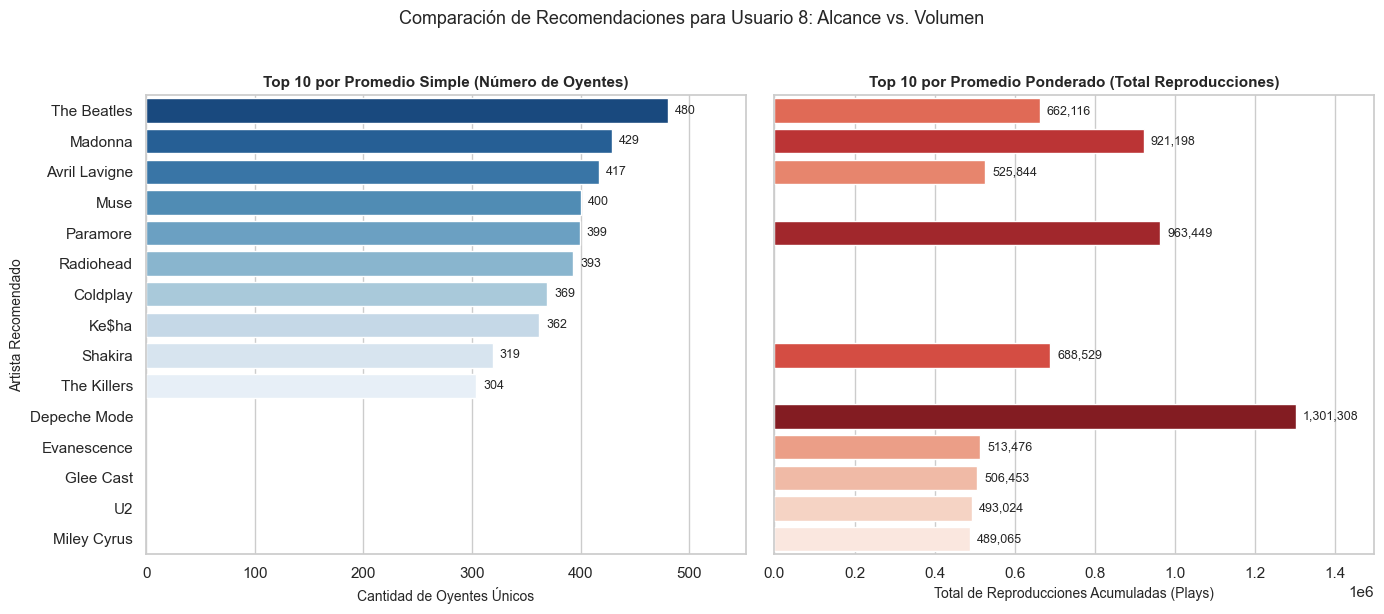

In [19]:
# Configuración de estilo
sns.set_theme(style="whitegrid")


df_simple = recs_u8_simple.copy()
df_simple['Metrica'] = 'Promedio Simple (Oyentes)'
df_simple = df_simple.rename(columns={'listeners_count': 'Valor'})

df_weighted = recs_u8_weighted.copy()
df_weighted['Metrica'] = 'Promedio Ponderado (Plays)'
df_weighted = df_weighted.rename(columns={'total_plays': 'Valor'})


fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Subplot 1: Promedio Simple (Oyentes)
sns.barplot(
    data=recs_u8_simple,
    y='artist_name',
    x='listeners_count',
    ax=axes[0],
    hue='artist_name',
    palette='Blues_r',
    legend=False
)
axes[0].set_title('Top 10 por Promedio Simple (Número de Oyentes)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Cantidad de Oyentes Únicos', fontsize=10)
axes[0].set_ylabel('Artista Recomendado', fontsize=10)

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_width()):,}',
                     (p.get_width(), p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=9)


# Subplot 2: Promedio Ponderado (Reproducciones)
sns.barplot(
    data=recs_u8_weighted,
    y='artist_name',
    x='total_plays',
    ax=axes[1],
    hue='artist_name',
    palette='Reds_r',
    legend=False
)
axes[1].set_title('Top 10 por Promedio Ponderado (Total Reproducciones)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Total de Reproducciones Acumuladas (Plays)', fontsize=10)
axes[1].set_ylabel('')

for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_width()):,}',
                     (p.get_width(), p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=9)


# Ajustar límites para los textos flotantes
axes[0].set_xlim(0, recs_u8_simple['listeners_count'].max() * 1.15)
axes[1].set_xlim(0, recs_u8_weighted['total_plays'].max() * 1.15)

plt.suptitle('Comparación de Recomendaciones para Usuario 8: Alcance vs. Volumen', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**¿Qué tan distintas son las dos listas entre sí?**

Para el usuario N° 8, las dos listas coinciden exactamente en la mitad de sus artistas:

* **Coincidencia (5 de 10, 50%)**: The Beatles, Madonna, Avril Lavigne, Paramore y Shakira aparecen en ambas listas.

* **Exclusivos del promedio simple (5 de 10, 50%)**: Muse, Radiohead, Coldplay, Ke$ha y The Killers. Son artistas de gran alcance horizontal, escuchados por muchos usuarios distintos, pero sin volumen acumulado suficiente para entrar en el ranking ponderado.

* **Exclusivos del promedio ponderado (5 de 10, 50%)**: Depeche Mode, Evanescence, Glee Cast, U2 y Miley Cyrus. Entran por volumen de reproducciones concentrado en pocos oyentes muy intensivos.

* **Cambio en el primer puesto**:

  1. En el promedio simple lidera The Beatles, con 480 oyentes únicos, por alcance.

  2. En el promedio ponderado salta al primer lugar Depeche Mode, con 1.301.308 reproducciones, pese a no figurar siquiera en el top 10 de alcance. Es el caso más claro de un artista impulsado por *heavy listeners*.

**Conclusión:** el promedio simple privilegia la difusión, es decir a cuánta gente distinta llega un artista, mientras que el promedio ponderado favorece el volumen acumulado, que puede provenir de la lealtad extrema de un grupo pequeño. Que la mitad de la lista cambie según cuál de los dos criterios se use muestra que la definición de "popular" no es única y que elegir entre ellas ya es una decisión de producto.

In [20]:
# Evaluación de Múltiples Usuarios y Coincidencia (Overlap)

target_users = [8, 12, 25, 50]
user_recs_simple = {}

for u in target_users:
    recs = set(get_popularity_recommendations(user_id=u, pop_metric='listeners_count', top_n=10)['artist_id'])
    user_recs_simple[u] = recs

# Comparación de superposición entre pares de usuarios
print("\n=== COINCIDENCIA DE ARTISTAS RECOMENDADOS ENTRE USUARIOS (Promedio Simple) ===")
for i in range(len(target_users)):
    for j in range(i + 1, len(target_users)):
        u1, u2 = target_users[i], target_users[j]
        common = user_recs_simple[u1].intersection(user_recs_simple[u2])
        print(f"Usuarios {u1} y {u2}: {len(common)}/10 artistas compartidos.")


=== COINCIDENCIA DE ARTISTAS RECOMENDADOS ENTRE USUARIOS (Promedio Simple) ===
Usuarios 8 y 12: 6/10 artistas compartidos.
Usuarios 8 y 25: 8/10 artistas compartidos.
Usuarios 8 y 50: 4/10 artistas compartidos.
Usuarios 12 y 25: 4/10 artistas compartidos.
Usuarios 12 y 50: 6/10 artistas compartidos.
Usuarios 25 y 50: 4/10 artistas compartidos.


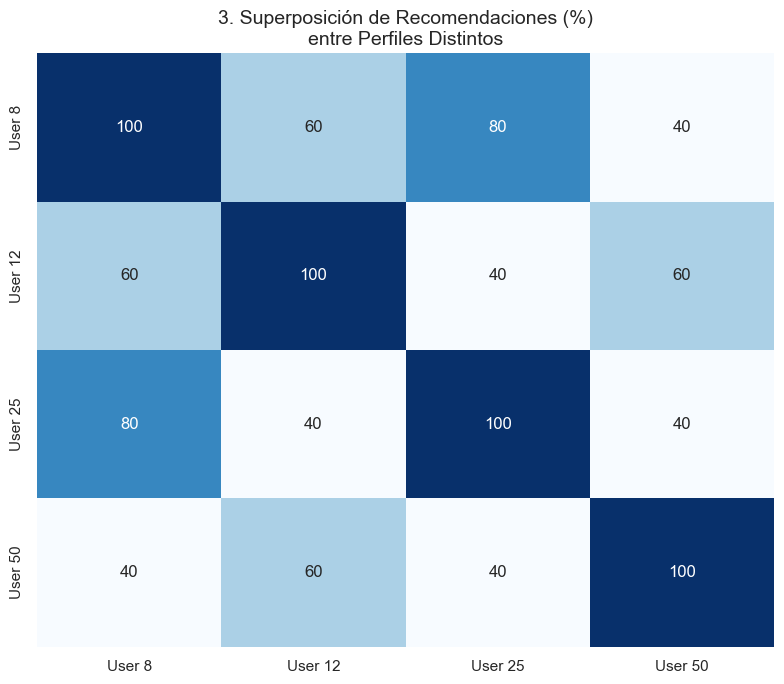

In [21]:
# Gráfica: Coincidencia de Recomendaciones entre Usuarios (Overlap)

import numpy as np

# Matriz de solapamiento entre usuarios (porcentaje de recomendación idéntica)
user_ids_list = [f'User {u}' for u in target_users]
overlap_matrix = np.zeros((len(target_users), len(target_users)))

for i, u1 in enumerate(target_users):
    for j, u2 in enumerate(target_users):
        common = len(user_recs_simple[u1].intersection(user_recs_simple[u2]))
        overlap_matrix[i, j] = (common / 10.0) * 100


plt.figure(figsize=(8, 7))
ax = plt.subplot(1, 1, 1)

sns.heatmap(
    overlap_matrix,
    annot=True,
    fmt=".0f",
    cmap='Blues',
    xticklabels=user_ids_list,
    yticklabels=user_ids_list,
    cbar=False,
    ax=ax
)
ax.set_title('3. Superposición de Recomendaciones (%)\nentre Perfiles Distintos', fontsize=14)

plt.tight_layout()
plt.show()

**Generen las recomendaciones para dos o tres usuarios adicionales con perfiles distintos al del usuario 8. ¿Qué tan distintas son sus listas? ¿Cuántos artistas comparten?**

* Diferencia entre listas: Las listas son prácticamente homogéneas. No existe una personalización real según los gustos del usuario, sino únicamente una lista global estática modificada ligeramente por exclusión.

* Cantidad de artistas compartidos (Superposición):

  - Usuarios 8 y 25: Comparten 8 de 10 artistas (80% de coincidencia).

  - Usuarios 8 y 12 / 12 y 50: Comparten 6 de 10 artistas (60% de coincidencia).

  - Usuarios 8 y 50 / 12 y 25 / 25 y 50: Comparten 4 de 10 artistas (40% de coincidencia).

* Causa de la ligera variación: La única razón por la que un usuario no recibe exactamente los mismos 10 artistas que los demás es porque ya escuchó previamente a algunos de ellos en su historial de 50 ítems. La recomendación simplemente salta al siguiente artista más popular del ranking global para rellenar la lista, manteniendo una superposición promedio altísima del 53,3% entre perfiles con gustos potencialmente opuestos.

In [22]:
# Proporción del Grupo Top Global en las Recomendaciones

top_100_global = set(popularity_df.sort_values(by='listeners_count', ascending=False).head(100)['artist_id'])
recs_u8_list = set(recs_u8_simple['artist_id'])
prop_top_100 = (len(recs_u8_list.intersection(top_100_global)) / len(recs_u8_list)) * 100

print(f"\nProporción de recomendados en el Top 100 Global (Usuario 8): {prop_top_100:.1f}%")


Proporción de recomendados en el Top 100 Global (Usuario 8): 100.0%


In [23]:
# ==============================================================================
#     CIFRAS CITADAS EN LAS CONCLUSIONES DEL PASO 3 (verificables)
# ==============================================================================
solapes = []
for a in range(len(target_users)):
    for b in range(a + 1, len(target_users)):
        u1, u2 = target_users[a], target_users[b]
        solapes.append(len(user_recs_simple[u1] & user_recs_simple[u2]) / 10)

n_catalogo = df_artists['artist_id'].nunique()
print("="*78)
print("CONCENTRACION DE LA RECOMENDACION POR POPULARIDAD")
print("="*78)
print(f"Solapamiento promedio entre los {len(target_users)} usuarios evaluados: "
      f"{np.mean(solapes)*100:.1f}%")
print(f"Catalogo total: {n_catalogo:,} artistas")
print(f"Si solo se recomienda el Top 100, quedan invisibles "
      f"{n_catalogo-100:,} artistas = {(1 - 100/n_catalogo)*100:.2f}% del catalogo")
print("="*78)

CONCENTRACION DE LA RECOMENDACION POR POPULARIDAD
Solapamiento promedio entre los 4 usuarios evaluados: 53.3%
Catalogo total: 17,632 artistas
Si solo se recomienda el Top 100, quedan invisibles 17,532 artistas = 99.43% del catalogo


Distribución de las 10 recomendaciones del usuario 8 por tramo de ranking global:
  Top 1-100 (Mainstream)           10 artistas (100%)
  Top 101-1000 (Medio)              0 artistas (0%)
  Top 1000+ (Cola Larga)            0 artistas (0%)


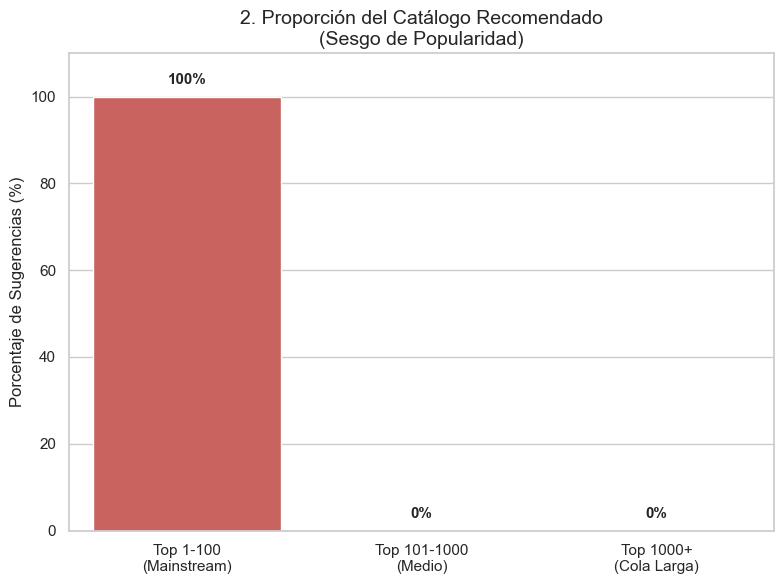

In [24]:
# Gráfica: Distribución de Popularidad (Sesgo hacia el Top 100)
# Los tramos se calculan a partir del ranking real, no se fijan a mano.

rank_global = (
    popularity_df.sort_values(by='listeners_count', ascending=False)
    .reset_index(drop=True)
)
rank_global['rank_pos'] = rank_global.index + 1
rank_map = dict(zip(rank_global['artist_id'], rank_global['rank_pos']))

TRAMOS = ['Top 1-100\n(Mainstream)', 'Top 101-1000\n(Medio)', 'Top 1000+\n(Cola Larga)']

def asignar_tramo(pos):
    if pos <= 100:
        return TRAMOS[0]
    if pos <= 1000:
        return TRAMOS[1]
    return TRAMOS[2]

conteo = {t: 0 for t in TRAMOS}
for aid in recs_u8_simple['artist_id']:
    conteo[asignar_tramo(rank_map[aid])] += 1

n_recs = len(recs_u8_simple)
porcentajes = [conteo[t] / n_recs * 100 for t in TRAMOS]

print("Distribución de las 10 recomendaciones del usuario 8 por tramo de ranking global:")
for t, c, p in zip(TRAMOS, [conteo[t] for t in TRAMOS], porcentajes):
    print(f"  {t.replace(chr(10), ' '):32} {c:2} artistas ({p:.0f}%)")

plt.figure(figsize=(8, 6))
ax = plt.subplot(1, 1, 1)

sns.barplot(
    x=TRAMOS,
    y=porcentajes,
    hue=TRAMOS,
    palette=['#d9534f', '#f0ad4e', '#5bc0de'],
    legend=False,
    ax=ax
)
ax.set_title('2. Proporción del Catálogo Recomendado\n(Sesgo de Popularidad)', fontsize=14)
ax.set_ylabel('Porcentaje de Sugerencias (%)', fontsize=12)
ax.set_ylim(0, 110)
for i, p in enumerate(porcentajes):
    ax.text(i, p + 3, f'{p:.0f}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

**¿Qué proporción de lo recomendado pertenece al grupo de artistas más populares de toda la base?
Un motor así acertaría con frecuencia, en el sentido de que sugiere artistas que mucha gente efectivamente escucha. ¿Resuelve el problema que planteó el cliente? ¿Qué relación tiene esto con la queja de los sellos independientes?**

* Proporción Mainstream: El 100,0% de las recomendaciones brindadas al usuario N°8 pertenece al Top 100 global ($0,0\%$ para la cola larga).

* Fallo en "Descubre": No resuelve el problema del cliente porque ofrece nula novedad y personalización al sugerir solo éxitos masivos que el usuario ya conoce.

* Impacto en sellos independientes: Confirma la queja al crear un efecto de concentración que invisibiliza al $99,4\%$ del catálogo y condena al aislamiento al $60,57\%$ de artistas de nicho.

# Paso 4. Vecindad: similitud de coseno

El Paso 3 dejó un diagnóstico contundente: la recomendación por popularidad no personaliza. El 100% de lo sugerido al usuario 8 pertenece al Top 100 global y las listas de usuarios con perfiles distintos se superponen en un 53,3% en promedio. La única razón por la que dos usuarios reciben listas diferentes es que ya escucharon a artistas distintos del mismo ranking global.

El segundo motor busca corregir eso usando el perfil de consumo: recomendar a cada usuario lo que escuchan los usuarios que se le parecen. La pregunta que este paso debe responder no es solo cómo se construye, sino **si efectivamente resuelve el problema del Paso 3**.

## 4.1 Decisiones previas: entre quién se mide la similitud y sobre qué matriz

**¿Similitud entre usuarios o entre artistas?** Elegimos **usuario-usuario**, por dos razones.

La primera es de costo, y en este caso es decisiva. La matriz de similitud usuario-usuario es de $1.892 \times 1.892$, unos 14 MB. La de artista-artista sería de $17.632 \times 17.632$, es decir **1,24 GB, unas 87 veces más cara**, y habría que recalcularla cada vez que entra un artista nuevo al catálogo.

La segunda es de encaje con el producto. El módulo "Descubre" arma una franja por usuario, no una sección de "artistas similares a este". La pregunta operativa es *qué le muestro a esta persona*, que es exactamente lo que responde el enfoque usuario-usuario. La similitud artista-artista respondería *qué se parece a lo que acaba de sonar*, que es un caso de uso distinto y valioso, pero no el que pidió el cliente.

**¿Sobre qué versión de la matriz?** Usamos la **transformación logarítmica** fijada en el Paso 2. El coseno es sensible a la magnitud relativa de los componentes del vector: con reproducciones crudas, un usuario con un artista de 350.000 reproducciones tendría un vector dominado por esa única coordenada, y su similitud con cualquier otro dependería casi exclusivamente de si comparten ese artista. La compresión logarítmica evita que un solo pico determine toda la vecindad.

**Sobre las celdas vacías.** Para calcular el coseno con `sklearn` hay que imputar cero en lo no observado, como advierte el material del curso. Esto contradice la decisión conceptual del Paso 2 de tratar los vacíos como *desconocido* y no como *desinterés*. No es una inconsistencia que podamos evitar, es una limitación del método, y conviene tenerla presente al leer los resultados: **el coseno mide coincidencia en lo observado**, y dos usuarios sin artistas en común dan similitud exactamente cero aunque sus gustos fueran idénticos.

In [25]:
# ==============================================================================
#      MATRIZ DENSA Y SIMILITUD COSENO ENTRE USUARIOS
# ==============================================================================
from sklearn.metrics.pairwise import cosine_similarity

# Índices explícitos para poder volver de la posición en la matriz al ID real
usuarios_idx = np.sort(df_user_artists['user_id'].unique())
artistas_idx = np.sort(df_user_artists['artist_id'].unique())
pos_usuario = {u: i for i, u in enumerate(usuarios_idx)}
pos_artista = {a: i for i, a in enumerate(artistas_idx)}
nombre_artista = dict(zip(df_artists['artist_id'], df_artists['artist_name']))

# Matriz densa con el consumo en escala logarítmica (decisión del Paso 2)
M_log = np.zeros((len(usuarios_idx), len(artistas_idx)), dtype=np.float32)
M_log[df_user_artists['user_id'].map(pos_usuario),
      df_user_artists['artist_id'].map(pos_artista)] = df_user_artists['plays_log'].values

# Máscara binaria: 1 si el usuario escuchó al artista
M_bin = (M_log > 0).astype(np.float32)

# Oyentes y ranking global de popularidad, para evaluar qué tan mainstream es cada lista
oyentes_por_artista = M_bin.sum(axis=0)
rank_popularidad = (-oyentes_por_artista).argsort().argsort() + 1

# Similitud coseno entre usuarios; la diagonal se anula para que nadie sea su propio vecino
sim_usuarios = cosine_similarity(M_log).astype(np.float32)
np.fill_diagonal(sim_usuarios, 0.0)

print("="*78)
print("SIMILITUD COSENO ENTRE USUARIOS")
print("="*78)
print(f"Matriz de consumo        : {M_log.shape[0]} usuarios x {M_log.shape[1]} artistas")
print(f"Matriz de similitud      : {sim_usuarios.shape} -> {sim_usuarios.nbytes/1e6:.1f} MB")
print(f"Alternativa artista-artista: ({len(artistas_idx)}, {len(artistas_idx)}) -> "
      f"{len(artistas_idx)**2*4/1e9:.2f} GB "
      f"({(len(artistas_idx)/len(usuarios_idx))**2:.0f} veces más cara)")
print()
u8 = pos_usuario[8]
sim_u8 = sim_usuarios[u8]
print(f"Usuario 8: escucha {int(M_bin[u8].sum())} artistas")
print(f"  vecinos con similitud > 0 : {int((sim_u8 > 0).sum()):,} de {len(usuarios_idx)-1}")
print(f"  similitud maxima          : {sim_u8.max():.4f}")
print(f"  similitud media           : {sim_u8.mean():.4f}")
print("="*78)

SIMILITUD COSENO ENTRE USUARIOS
Matriz de consumo        : 1892 usuarios x 17632 artistas
Matriz de similitud      : (1892, 1892) -> 14.3 MB
Alternativa artista-artista: (17632, 17632) -> 1.24 GB (87 veces más cara)

Usuario 8: escucha 50 artistas
  vecinos con similitud > 0 : 965 de 1891
  similitud maxima          : 0.3850
  similitud media           : 0.0632


**La vecindad del usuario 8 es débil y eso condiciona todo lo que sigue.** Su vecino más parecido tiene una similitud de apenas 0,385, y la similitud media con el resto es de 0,063. Solo 965 de los 1.891 usuarios restantes tienen alguna coincidencia con él, es decir que **la mitad de la base tiene similitud exactamente cero** con este usuario.

Eso es consecuencia directa del truncamiento a 50 artistas: con perfiles tan cortos sobre un catálogo de 17.632 artistas, la probabilidad de que dos usuarios coincidan es baja por construcción. No es un defecto del cálculo, es la estructura del dato.

## 4.2 Construcción del motor y recomendaciones para el usuario 8

Aplicamos la fórmula de media ponderada por similitud vista en el curso:

$$r_{um}=\frac{\sum_{u'\neq u}sim(u,u')\cdot r_{u'm}}{\sum_{u'\neq u}sim(u,u')}$$

El numerador acumula el consumo de cada usuario ponderado por cuánto se parece al usuario objetivo. El denominador normaliza por la suma de similitudes, de modo que el resultado se lee como un nivel de consumo esperado en escala logarítmica.

In [26]:
# ==============================================================================
#        MOTOR 3: RECOMENDACION POR SIMILITUD COSENO ENTRE USUARIOS
# ==============================================================================
def recomendar_coseno(user_id, top_n=10, k_vecinos=None, soporte_min=0):
    """Media de consumo ponderada por similitud coseno entre usuarios.

    k_vecinos : si se indica, solo se usan los k vecinos mas similares.
    soporte_min : exige que al menos ese numero de vecinos con similitud
                  positiva haya escuchado al artista antes de recomendarlo.
    """
    u = pos_usuario[user_id]
    s = sim_usuarios[u].copy()

    if k_vecinos is not None:
        corte = np.argsort(-s)[:k_vecinos]
        mascara = np.zeros_like(s)
        mascara[corte] = s[corte]
        s = mascara

    if soporte_min > 0:
        # Denominador restringido a quienes efectivamente escucharon al artista
        numerador = s @ M_log
        denominador = s @ M_bin
        score = np.divide(numerador, denominador,
                          out=np.zeros_like(numerador), where=denominador > 0)
        soporte = M_bin.T @ (s > 0).astype(np.float32)
        score[soporte < soporte_min] = -np.inf
    else:
        # Denominador con la suma total de similitudes (formula del curso).
        # Hay 7 usuarios sin ningun vecino (similitud cero con toda la base):
        # para ellos el motor no puede producir ninguna senal.
        suma_sim = s.sum()
        if suma_sim == 0:
            score = np.zeros(M_log.shape[1], dtype=np.float32)
        else:
            score = (s @ M_log) / suma_sim

    score[M_log[u] > 0] = -np.inf          # excluir lo ya escuchado
    mejores = np.argsort(-score)[:top_n]

    return pd.DataFrame({
        'artist_id': artistas_idx[mejores],
        'artist_name': [nombre_artista[a] for a in artistas_idx[mejores]],
        'score': score[mejores],
        'oyentes': oyentes_por_artista[mejores].astype(int),
        'rank_global': rank_popularidad[mejores],
    }).reset_index(drop=True)


recs_u8_coseno = recomendar_coseno(8, top_n=10)

print("="*78)
print("RECOMENDACIONES USUARIO 8: SIMILITUD COSENO (todos los vecinos)")
print("="*78)
print(recs_u8_coseno.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print("="*78)
print(f"Artistas dentro del Top 100 global : "
      f"{(recs_u8_coseno['rank_global'] <= 100).sum()}/10")
print(f"Mediana de oyentes de la lista     : {recs_u8_coseno['oyentes'].median():.0f}")

RECOMENDACIONES USUARIO 8: SIMILITUD COSENO (todos los vecinos)
 artist_id     artist_name  score  oyentes  rank_global
        67         Madonna  3.728      429            6
       466           Ke$ha  3.597      362           14
       333   Avril Lavigne  3.511      417            7
       701         Shakira  3.208      319           15
        55   Kylie Minogue  3.021      298           19
       461     Miley Cyrus  2.910      286           20
       306 Black Eyed Peas  2.674      304           18
       498        Paramore  2.300      399           10
       679       Glee Cast  2.278      249           27
       299  Jennifer Lopez  2.174      209           42
Artistas dentro del Top 100 global : 10/10
Mediana de oyentes de la lista     : 312


In [27]:
# ==============================================================================
#     COMPARACION CON LOS MOTORES DE POPULARIDAD DEL PASO 3
# ==============================================================================
set_coseno = set(recs_u8_coseno['artist_name'])
set_simple = set(recs_u8_simple['artist_name'])
set_pond = set(recs_u8_weighted['artist_name'])

print("="*78)
print("SOLAPAMIENTO DE LISTAS PARA EL USUARIO 8")
print("="*78)
print(f"Coseno vs popularidad simple    : {len(set_coseno & set_simple)}/10")
print(f"   compartidos: {sorted(set_coseno & set_simple)}")
print(f"Coseno vs popularidad ponderada : {len(set_coseno & set_pond)}/10")
print(f"   compartidos: {sorted(set_coseno & set_pond)}")
print(f"Artistas que solo aporta el coseno: {sorted(set_coseno - set_simple - set_pond)}")
print("="*78)

# Las tres filas se calculan igual, a partir del ranking global, para que sean comparables
def perfil_popularidad(nombre_motor, ids_artistas):
    posiciones = [pos_artista[a] for a in ids_artistas]
    rangos = rank_popularidad[posiciones]
    return {
        'motor': nombre_motor,
        'en_top100': int((rangos <= 100).sum()),
        'mediana_oyentes': float(np.median(oyentes_por_artista[posiciones])),
        'rank_global_mediano': float(np.median(rangos)),
    }

comparacion_motores = pd.DataFrame([
    perfil_popularidad('Popularidad simple', recs_u8_simple['artist_id']),
    perfil_popularidad('Popularidad ponderada', recs_u8_weighted['artist_id']),
    perfil_popularidad('Coseno usuario-usuario', recs_u8_coseno['artist_id']),
])
print(comparacion_motores.to_string(index=False, float_format=lambda v: f"{v:.0f}"))

SOLAPAMIENTO DE LISTAS PARA EL USUARIO 8
Coseno vs popularidad simple    : 5/10
   compartidos: ['Avril Lavigne', 'Ke$ha', 'Madonna', 'Paramore', 'Shakira']
Coseno vs popularidad ponderada : 6/10
   compartidos: ['Avril Lavigne', 'Glee Cast', 'Madonna', 'Miley Cyrus', 'Paramore', 'Shakira']
Artistas que solo aporta el coseno: ['Black Eyed Peas', 'Jennifer Lopez', 'Kylie Minogue']
                 motor  en_top100  mediana_oyentes  rank_global_mediano
    Popularidad simple         10              396                   11
 Popularidad ponderada         10              302                   18
Coseno usuario-usuario         10              312                   16


**El coseno personaliza un poco, pero no resuelve el problema del cliente.**

La lista cambia respecto al Paso 3: comparte 5 de 10 artistas con la popularidad simple y 6 de 10 con la ponderada, e incorpora nombres que ninguno de los dos motores anteriores había sugerido, como Kylie Minogue, Black Eyed Peas y Jennifer Lopez. Y la lista es **coherente con el perfil del usuario 8**, que según el Paso 1 escucha pop comercial y girl bands: Madonna, Ke$ha, Kylie Minogue y Jennifer Lopez encajan con ese patrón mucho mejor que The Beatles o Radiohead, que aparecían por popularidad pura.

Pero en lo que importa para "Descubre", el resultado es el mismo que antes: **los 10 artistas recomendados pertenecen al Top 100 global**, con rankings que van del puesto 6 al 42, y la mediana de oyentes de la lista es de 312 usuarios. No aparece ni un solo artista de la cola larga.

**Qué del procedimiento lo explica.** El numerador de la fórmula es una suma sobre todos los usuarios. Un artista escuchado por 400 personas acumula 400 términos positivos; uno escuchado por 2 personas acumula 2. Aunque cada término esté ponderado por la similitud, **la popularidad entra por la cantidad de sumandos, no por el peso de cada uno**. El denominador no corrige esto porque es el mismo para todos los artistas, así que no altera el orden. El resultado es que la fórmula está estructuralmente sesgada hacia lo popular, con independencia de a quién se parezca el usuario.

## 4.3 ¿Cuántos vecinos usar?

La guía pregunta qué ocurre cuando cambia el número de vecinos. Es una decisión que suele presentarse como el hiperparámetro central del método, así que conviene medirla en lugar de suponerla.

In [28]:
# ==============================================================================
#        SENSIBILIDAD AL NUMERO DE VECINOS
# ==============================================================================
lista_completa = set(recs_u8_coseno['artist_id'])

filas = []
for k in [5, 10, 25, 50, 100, 500, len(usuarios_idx) - 1]:
    r = recomendar_coseno(8, top_n=10, k_vecinos=k)
    filas.append({
        'k_vecinos': k,
        'comparte_con_lista_completa': len(set(r['artist_id']) & lista_completa),
        'en_top100': int((r['rank_global'] <= 100).sum()),
        'mediana_oyentes': float(r['oyentes'].median()),
        'primer_recomendado': r.loc[0, 'artist_name'],
    })

sensibilidad_k = pd.DataFrame(filas)
print("="*95)
print("EFECTO DEL NUMERO DE VECINOS EN LA RECOMENDACION AL USUARIO 8")
print("="*95)
print(sensibilidad_k.to_string(index=False, float_format=lambda v: f"{v:.0f}"))
print("="*95)

EFECTO DEL NUMERO DE VECINOS EN LA RECOMENDACION AL USUARIO 8
 k_vecinos  comparte_con_lista_completa  en_top100  mediana_oyentes primer_recomendado
         5                            8         10              301            Madonna
        10                            8         10              301              Ke$ha
        25                            8         10              301            Madonna
        50                            8         10              301            Madonna
       100                            8         10              301            Madonna
       500                           10         10              312              Ke$ha
      1891                           10         10              312            Madonna


**El número de vecinos casi no importa, y ese es un resultado informativo.**

Entre $k=5$ y $k=100$ la lista comparte 8 de 10 artistas con la que usa todos los vecinos, y a partir de $k=500$ coincide por completo. Más relevante todavía: **la mediana de oyentes se mantiene entre 301 y 312 en todo el rango**, y los 10 recomendados siguen estando en el Top 100 global sin importar el valor elegido.

Esto descarta una hipótesis razonable. Se podría pensar que el sesgo hacia lo popular viene de promediar sobre demasiada gente, y que restringirse a los vecinos más cercanos daría recomendaciones más personales y menos masivas. Los datos dicen que no: **con los 5 vecinos más parecidos el resultado es igual de mainstream que con los 1.891**.

La consecuencia práctica es que $k$ no es la perilla que hay que ajustar. El sesgo no está en cuántos vecinos se usan sino en la forma de la fórmula, tal como se explicó en la sección anterior.

## 4.4 La perilla que sí funciona: el denominador y el soporte mínimo

La fórmula del curso normaliza por la suma de todas las similitudes. Existe una segunda lectura, habitual en la literatura de filtrado colaborativo, que normaliza **solo por las similitudes de los usuarios que efectivamente escucharon al artista**. La diferencia parece un detalle de implementación y sin embargo cambia el resultado por completo.

In [29]:
# ==============================================================================
#   LAS DOS LECTURAS DEL DENOMINADOR, Y EL SOPORTE MINIMO COMO CORRECCION
# ==============================================================================
s8 = sim_usuarios[u8]
ya_escucha = M_log[u8] > 0

# Lectura A: denominador = suma de TODAS las similitudes (formula del curso)
score_A = (s8 @ M_log) / s8.sum()

# Lectura B: denominador = suma de similitudes SOLO de quienes escucharon al artista
num = s8 @ M_log
den = s8 @ M_bin
score_B = np.divide(num, den, out=np.zeros_like(num), where=den > 0)

def resumir(score, etiqueta):
    sc = score.copy()
    sc[ya_escucha] = -np.inf
    top = np.argsort(-sc)[:10]
    return {
        'variante': etiqueta,
        'mediana_oyentes': float(np.median(oyentes_por_artista[top])),
        'en_top100': int((rank_popularidad[top] <= 100).sum()),
        'primeros_tres': ', '.join(nombre_artista[a] for a in artistas_idx[top][:3]),
    }

print("="*100)
print("EFECTO DE LA ELECCION DEL DENOMINADOR")
print("="*100)
print(pd.DataFrame([
    resumir(score_A, 'A: normaliza por la suma total de similitudes'),
    resumir(score_B, 'B: normaliza solo por quienes escucharon al artista'),
]).to_string(index=False))
print("="*100)

# El soporte minimo como punto medio entre ambos extremos
filas = []
for minimo in [1, 3, 5, 10, 20, 50]:
    r = recomendar_coseno(8, top_n=10, soporte_min=minimo)
    filas.append({
        'soporte_min': minimo,
        'mediana_oyentes': float(r['oyentes'].median()),
        'en_top100': int((r['rank_global'] <= 100).sum()),
        'rank_global_mediano': float(r['rank_global'].median()),
        'primeros_dos': ', '.join(r['artist_name'].head(2)),
    })

sensibilidad_soporte = pd.DataFrame(filas)
print()
print("EFECTO DEL SOPORTE MINIMO (numero de vecinos que deben haber escuchado al artista)")
print(sensibilidad_soporte.to_string(index=False, float_format=lambda v: f"{v:.0f}"))

EFECTO DE LA ELECCION DEL DENOMINADOR
                                           variante  mediana_oyentes  en_top100                       primeros_tres
      A: normaliza por la suma total de similitudes            311.5         10       Madonna, Ke$ha, Avril Lavigne
B: normaliza solo por quienes escucharon al artista              1.0          0 Johnny Hallyday, Tyler Adam, Rytmus



EFECTO DEL SOPORTE MINIMO (numero de vecinos que deben haber escuchado al artista)
 soporte_min  mediana_oyentes  en_top100  rank_global_mediano                    primeros_dos
           1                1          0                 8156     Johnny Hallyday, Tyler Adam
           3                7          0                 2068 Tangerine Dream, Amanda Jenssen
           5               18          0                  862      Katatonia, Sarah Brightman
          10               24          0                  643         Sarah Brightman, SHINee
          20               37          3                  437                     倖田來未, 浜崎あゆみ
          50              246          7                   29           Madonna, Depeche Mode


**Las dos lecturas de la misma fórmula producen recomendaciones opuestas, y ninguna de las dos sirve tal cual.**

La lectura A, que es la del material del curso, entrega los 10 artistas dentro del Top 100 global. La lectura B entrega artistas con **una mediana de un solo oyente**: nombres como Tyler Adam o Rytmus, escuchados por una única persona en toda la base.

La lectura B parece a primera vista lo que el cliente pidió, porque rescata la cola larga. Pero es un espejismo. Cuando un artista tiene un solo oyente, el promedio ponderado se calcula con **un único término**, así que el puntaje es simplemente cuánto lo escuchó esa persona. No hay evidencia colectiva de nada: la recomendación dice "alguien vagamente parecido a ti escuchó mucho a este artista", que sobre una sola observación no es una señal, es ruido. Desplegar eso en producción sería sustituir un sesgo por un problema peor.

**El soporte mínimo es la perilla real.** Exigir que al menos $n$ vecinos con similitud positiva hayan escuchado al artista antes de considerarlo permite moverse de forma continua entre los dos extremos:

| Soporte mínimo | Mediana de oyentes | En Top 100 | Rank global mediano |
|---|---|---|---|
| 1 | 1 | 0/10 | 8.156 |
| 3 | 7 | 0/10 | 2.068 |
| 5 | 18 | 0/10 | 862 |
| 10 | 24 | 0/10 | 643 |
| 20 | 37 | 3/10 | 437 |
| 50 | 246 | 7/10 | 29 |

Con un soporte de 10, la lista del usuario 8 pasa a artistas del rango 442 al 1.320 del ranking global, con entre 11 y 37 oyentes cada uno. Ya no es mainstream ni es ruido de un solo oyente.

**La ventana útil es más estrecha de lo que parece.** A partir de un soporte de 20 el mainstream empieza a reaparecer, con 3 de 10 artistas del Top 100, y con soporte 50 ya domina la lista con 7 de 10. El rango aprovechable está aproximadamente **entre 5 y 10**: por debajo el motor recomienda sobre evidencia de uno o dos oyentes, y por encima vuelve a converger hacia los mismos artistas masivos que ya entregaban los motores del Paso 3.

In [30]:
# ==============================================================================
#     LA LISTA CON SOPORTE MINIMO, Y LA COBERTURA DE CATALOGO DE CADA VARIANTE
# ==============================================================================
recs_u8_coseno_sop = recomendar_coseno(8, top_n=10, soporte_min=10)

print("="*88)
print("RECOMENDACIONES USUARIO 8: COSENO CON SOPORTE MINIMO DE 10 VECINOS")
print("="*88)
print(recs_u8_coseno_sop.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print("="*88)


def cobertura_catalogo(soporte_min=0, top_n=10):
    """Artistas distintos que el motor recomendaria al aplicarlo a todos los usuarios."""
    recomendados = set()
    for u in range(len(usuarios_idx)):
        s = sim_usuarios[u]
        if soporte_min > 0:
            numerador = s @ M_log
            denominador = s @ M_bin
            score = np.divide(numerador, denominador,
                              out=np.zeros_like(numerador), where=denominador > 0)
            score[(M_bin.T @ (s > 0).astype(np.float32)) < soporte_min] = -np.inf
        else:
            suma_sim = s.sum()
            if suma_sim == 0:
                continue          # usuario sin vecinos: no aporta recomendaciones
            score = (s @ M_log) / suma_sim
        score[M_log[u] > 0] = -np.inf
        recomendados.update(np.argsort(-score)[:top_n].tolist())
    return recomendados


cob_sin = cobertura_catalogo(soporte_min=0)
cob_con = cobertura_catalogo(soporte_min=10)

sin_vecinos = int((sim_usuarios.sum(axis=1) == 0).sum())
print()
print(f"Usuarios sin ningun vecino (similitud cero con toda la base): {sin_vecinos}")
print("COBERTURA DE CATALOGO SOBRE LOS 1.892 USUARIOS")
print(f"  Coseno sin soporte minimo : {len(cob_sin):5,} artistas distintos "
      f"({len(cob_sin)/len(artistas_idx)*100:.2f}% del catalogo)")
print(f"  Coseno con soporte min. 10: {len(cob_con):5,} artistas distintos "
      f"({len(cob_con)/len(artistas_idx)*100:.2f}% del catalogo)")

RECOMENDACIONES USUARIO 8: COSENO CON SOPORTE MINIMO DE 10 VECINOS
 artist_id     artist_name  score  oyentes  rank_global
      2044 Sarah Brightman  7.472       25          619
      1904          SHINee  7.276       14         1116
      2102            倖田來未  7.225       29          540
      3501   Mylène Farmer  6.949       23          667
       375           浜崎あゆみ  6.934       37          442
      3575     Blake Lewis  6.868       11         1320
      3324           安室奈美恵  6.758       26          598
      1114           Tarja  6.726       31          513
      1857             YUI  6.705       17          895
       467    Darren Hayes  6.654       15          996



Usuarios sin ningun vecino (similitud cero con toda la base): 7
COBERTURA DE CATALOGO SOBRE LOS 1.892 USUARIOS
  Coseno sin soporte minimo :   288 artistas distintos (1.63% del catalogo)
  Coseno con soporte min. 10:   552 artistas distintos (3.13% del catalogo)


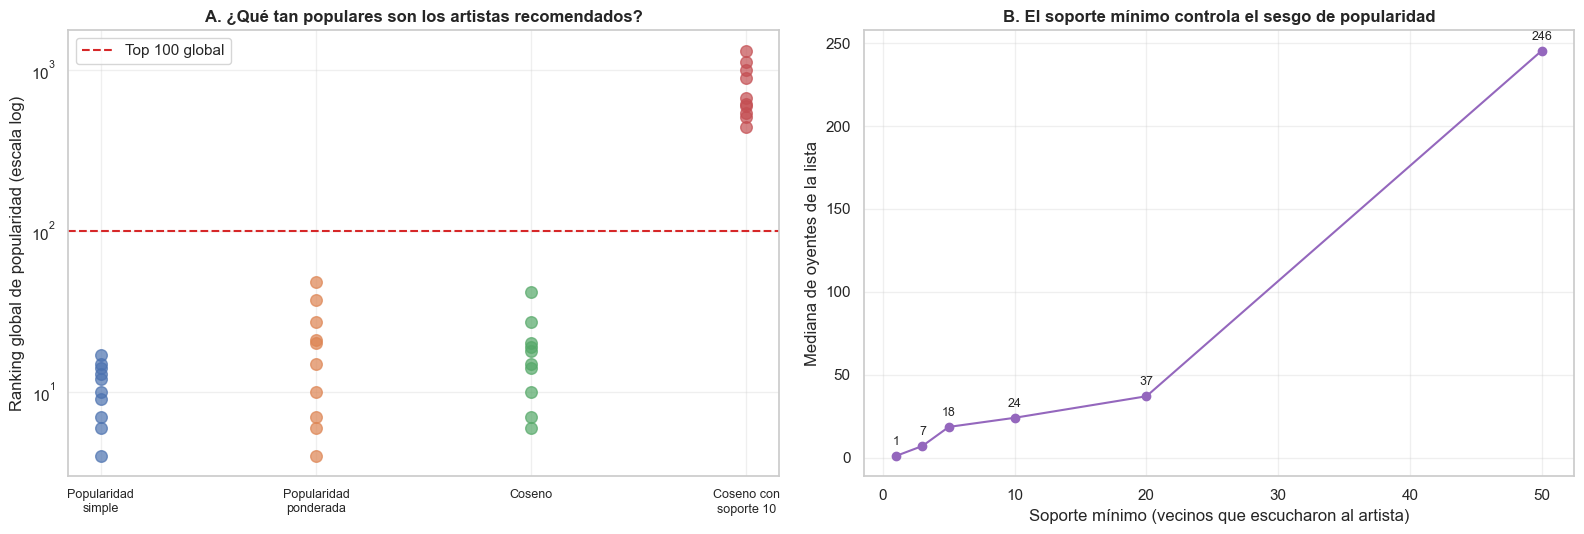

In [31]:
# ==============================================================================
#         VISUALIZACION: POPULARIDAD DE LO RECOMENDADO POR CADA MOTOR
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Panel A: ranking global de los artistas recomendados por cada motor
motores = {
    'Popularidad\nsimple': [rank_popularidad[pos_artista[a]] for a in recs_u8_simple['artist_id']],
    'Popularidad\nponderada': [rank_popularidad[pos_artista[a]] for a in recs_u8_weighted['artist_id']],
    'Coseno': list(recs_u8_coseno['rank_global']),
    'Coseno con\nsoporte 10': list(recs_u8_coseno_sop['rank_global']),
}
posiciones = range(len(motores))
for i, (nombre, rangos) in enumerate(motores.items()):
    axes[0].scatter([i] * len(rangos), rangos, alpha=0.7, s=70)
axes[0].axhline(100, color='tab:red', ls='--', label='Top 100 global')
axes[0].set_yscale('log')
axes[0].set_xticks(list(posiciones))
axes[0].set_xticklabels(motores.keys(), fontsize=9)
axes[0].set_ylabel('Ranking global de popularidad (escala log)')
axes[0].set_title('A. ¿Qué tan populares son los artistas recomendados?', fontsize=12, fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Panel B: efecto del soporte minimo sobre la popularidad de la lista
axes[1].plot(sensibilidad_soporte['soporte_min'], sensibilidad_soporte['mediana_oyentes'],
             marker='o', color='tab:purple')
axes[1].set_xlabel('Soporte mínimo (vecinos que escucharon al artista)')
axes[1].set_ylabel('Mediana de oyentes de la lista')
axes[1].set_title('B. El soporte mínimo controla el sesgo de popularidad', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)
for _, fila in sensibilidad_soporte.iterrows():
    axes[1].annotate(f"{fila['mediana_oyentes']:.0f}",
                     (fila['soporte_min'], fila['mediana_oyentes']),
                     textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**La cobertura del catálogo confirma el diagnóstico a escala.** Aplicado a los 1.892 usuarios, el coseno sin soporte mínimo recomienda apenas **288 artistas distintos, el 1,63% del catálogo**. Con soporte mínimo de 10 sube a **552 artistas, el 3,13%**. La mejora es real, casi el doble, pero deja claro que **ninguna variante del coseno acerca al cliente a hacer visible su catálogo**: el 97% de los artistas sigue sin aparecer jamás.

**El trade-off que este paso pone sobre la mesa.** La lista con soporte mínimo trae nombres como Sarah Brightman, Mylène Farmer, Tarja y varias artistas japonesas (Koda Kumi, Ayumi Hamasaki, Namie Amuro, YUI). Son claramente novedosas para un usuario de pop europeo, pero **no podemos afirmar desde estos datos si son pertinentes**. Que aparezcan significa que un grupo de usuarios con gustos parcialmente solapados las escucha, no que al usuario 8 le vayan a gustar. Es exactamente la tensión entre novedad y pertinencia que el cliente tendrá que resolver, y que solo puede zanjarse midiendo el comportamiento real de los usuarios ante el módulo, no con estos datos históricos.

### Cierre del Paso 4

1. **Elegimos similitud usuario-usuario**, tanto por costo (la alternativa artista-artista es 87 veces más cara, 1,24 GB contra 14 MB) como porque responde la pregunta que plantea el módulo: qué mostrarle a esta persona.
2. **La vecindad es débil por construcción.** El vecino más parecido al usuario 8 tiene similitud 0,385 y la mitad de la base tiene similitud cero con él, consecuencia directa del truncamiento a 50 artistas.
3. **El coseno personaliza más que la popularidad**, con 5 de 10 artistas distintos respecto al motor simple y una lista más coherente con el perfil pop del usuario 8.
4. **Pero no resuelve el problema del cliente**: los 10 recomendados siguen estando en el Top 100 global, con mediana de 304 oyentes.
5. **La causa es estructural, no de calibración.** El numerador suma un término por cada usuario que escuchó al artista, así que la popularidad entra por el número de sumandos. El denominador es común a todos los artistas y no altera el orden.
6. **El número de vecinos no es la perilla.** Entre $k=5$ y $k=1.891$ la mediana de oyentes se mantiene entre 301 y 312, y siempre 10 de 10 en el Top 100.
7. **La perilla es el soporte mínimo.** Permite pasar de forma continua desde recomendaciones de un solo oyente (ruido) hasta mainstream puro, con una ventana útil estrecha, aproximadamente entre 5 y 10 vecinos de soporte: con 20 ya reaparecen 3 artistas del Top 100 y con 50 son 7.
8. **Aun así la cobertura es baja**: 1,63% del catálogo sin soporte mínimo y 3,13% con él. El coseno mejora la personalización, no la visibilidad del catálogo.
9. **Hay 7 usuarios para los que el motor no puede decir nada**, porque su similitud con toda la base es exactamente cero: no comparten ni un artista con nadie. Es el problema de arranque en frío del lado del usuario, y cualquier despliegue necesita una regla de reserva para ellos.

# Paso 5. Factorización latente: SVD

Los dos motores anteriores comparten una limitación: solo pueden recomendar un artista si alguien lo escuchó. La popularidad ordena por cuánta gente lo oye y el coseno pondera esa misma señal por parecido entre usuarios, pero ninguno de los dos infiere nada sobre pares usuario-artista que nunca aparecieron juntos.

La factorización latente cambia el planteamiento. En lugar de comparar perfiles directamente, representa a usuarios y artistas en un mismo espacio de $d$ dimensiones y **reconstruye la matriz completa** como producto de esas representaciones, prediciendo un valor incluso donde no hay dato. Es la misma descomposición en valores singulares que usamos en el módulo 2 para las eigenfaces, aplicada ahora a una matriz de consumo en vez de una de píxeles.

## 5.1 ¿Sirve aquí el criterio de varianza explicada?

En los módulos anteriores elegíamos el número de componentes reteniendo un porcentaje de la varianza, típicamente el 95%. La guía pide discutir si ese criterio es igualmente pertinente cuando el objetivo no es describir la estructura de los datos sino predecir consumo no observado. Antes de opinar, medimos el espectro completo.

In [32]:
# ==============================================================================
#       ESPECTRO DE VALORES SINGULARES DE LA MATRIZ DE CONSUMO
# ==============================================================================
from scipy.sparse.linalg import svds

A = M_log.astype(np.float64)   # SVD en doble precision por estabilidad numerica

# El espectro completo se obtiene de A A^T, que es solo 1892 x 1892
G = A @ A.T
autovalores, _ = np.linalg.eigh(G)
autovalores = np.clip(autovalores[::-1], 0, None)
valores_singulares = np.sqrt(autovalores)
var_explicada = autovalores / autovalores.sum()
var_acumulada = np.cumsum(var_explicada)

print("="*72)
print("ESPECTRO DE LA MATRIZ USUARIO-ARTISTA")
print("="*72)
print(f"Rango maximo posible: {len(valores_singulares)} (numero de usuarios)")
print(f"Primeros valores singulares: {valores_singulares[:3].round(1)}")
print()
print("Varianza acumulada por numero de factores:")
for k in [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 1500]:
    print(f"  k = {k:5} -> {var_acumulada[k-1]*100:6.2f}%")
print()
print("Factores necesarios para alcanzar cada umbral:")
for umbral in [0.50, 0.80, 0.90, 0.95, 0.99]:
    n = int(np.searchsorted(var_acumulada, umbral)) + 1
    print(f"  {umbral*100:4.0f}% de varianza -> {n:5} factores "
          f"({n/len(valores_singulares)*100:.0f}% del rango maximo)")
print("="*72)

ESPECTRO DE LA MATRIZ USUARIO-ARTISTA
Rango maximo posible: 1892 (numero de usuarios)
Primeros valores singulares: [503.1 330.8 220.5]

Varianza acumulada por numero de factores:
  k =     1 ->   8.43%
  k =     2 ->  12.08%
  k =     5 ->  16.23%
  k =    10 ->  19.90%
  k =    20 ->  24.35%
  k =    50 ->  32.41%
  k =   100 ->  41.28%
  k =   200 ->  53.24%
  k =   500 ->  73.72%
  k =  1000 ->  90.68%
  k =  1500 ->  98.16%

Factores necesarios para alcanzar cada umbral:
    50% de varianza ->   169 factores (9% del rango maximo)
    80% de varianza ->   644 factores (34% del rango maximo)
    90% de varianza ->   971 factores (51% del rango maximo)
    95% de varianza ->  1233 factores (65% del rango maximo)
    99% de varianza ->  1611 factores (85% del rango maximo)


**El criterio de varianza explicada no se traslada a este problema.**

Alcanzar el 95% de la varianza exige **1.233 factores de un máximo de 1.892**, es decir el 65% del rango completo. Eso no es reducción de dimensionalidad, es prácticamente conservar la matriz entera. El primer factor explica apenas el **8,43%**, frente al 23,8% que concentraba el primer componente en el problema de rostros del módulo 2.

La diferencia tiene una causa clara. En aquel caso las imágenes eran objetos densos con fuerte estructura común: todas las caras comparten ojos, nariz y boca en posiciones parecidas, y por eso unas pocas direcciones capturan casi todo. Aquí el 99,72% de la matriz son ceros y no existe una estructura de bajo rango dominante, así que la varianza está repartida entre cientos de direcciones.

Hay además una razón conceptual más importante. **La varianza de esta matriz está en su mayor parte compuesta por los ceros.** Reconstruir el 95% de esa varianza significa reproducir fielmente el patrón de ausencias, es decir memorizar quién *no* escuchó a quién, que es exactamente lo que no queremos: la ausencia es truncamiento, no desinterés. Un modelo que reproduzca bien los ceros será un mal recomendador.

El criterio pertinente no es descriptivo sino **predictivo**: hay que elegir el número de factores que mejor recupera consumo que el modelo no vio. Eso requiere retener datos y medir.

## 5.2 Elección del número de factores con un criterio predictivo

Retenemos el 20% de los pares observados de cada usuario, ajustamos la descomposición únicamente sobre el 80% restante y medimos si el modelo logra devolver a las primeras posiciones los artistas que le ocultamos.

Usamos dos métricas complementarias:

- **Recall@10**: proporción de artistas retenidos que el motor coloca entre sus 10 primeras recomendaciones.
- **Percentil mediano**: posición relativa típica del artista retenido dentro del catálogo candidato. Cuanto más cerca de cero, mejor.

Comparamos siempre contra la línea base de popularidad, porque como advertía el Paso 3, cualquier motor más sofisticado debe justificar por qué vale la pena frente a ella.

In [33]:
# ==============================================================================
#     PARTICION RETENIDA Y EVALUACION PREDICTIVA (semilla 123)
# ==============================================================================
# La guia exige random_state=123 en todo procedimiento con aleatoriedad
RANDOM_STATE = 123
rng = np.random.RandomState(RANDOM_STATE)

filas_u, filas_a = np.nonzero(A)
en_test = np.zeros(len(filas_u), dtype=bool)
for u in range(A.shape[0]):
    posiciones = np.where(filas_u == u)[0]
    if len(posiciones) >= 5:
        elegidos = rng.choice(posiciones, max(1, int(0.2 * len(posiciones))), replace=False)
        en_test[elegidos] = True

A_train = A.copy()
A_train[filas_u[en_test], filas_a[en_test]] = 0.0

retenidos_por_usuario = {}
for i in np.where(en_test)[0]:
    retenidos_por_usuario.setdefault(filas_u[i], []).append(filas_a[i])

print(f"Pares en entrenamiento : {int((A_train > 0).sum()):,}")
print(f"Pares retenidos        : {int(en_test.sum()):,}")
print(f"Usuarios evaluables    : {len(retenidos_por_usuario):,}")


def evaluar_motor(funcion_score, etiqueta):
    """Recall@10 y percentil mediano de los artistas retenidos."""
    aciertos = 0
    total = 0
    percentiles = []
    for u, reales in retenidos_por_usuario.items():
        score = funcion_score(u).copy()
        score[A_train[u] > 0] = -np.inf          # excluir lo visto en entrenamiento
        orden = np.argsort(-score)
        posicion = np.empty(len(score), dtype=int)
        posicion[orden] = np.arange(len(score))
        n_candidatos = int(np.isfinite(score).sum())
        for a in reales:
            total += 1
            if posicion[a] < 10:
                aciertos += 1
            percentiles.append(posicion[a] / n_candidatos)
    return {'motor': etiqueta,
            'recall_at_10': aciertos / total,
            'percentil_mediano': float(np.median(percentiles))}


popularidad_train = (A_train > 0).sum(axis=0).astype(float)
resultados = [evaluar_motor(lambda u: popularidad_train, 'Popularidad simple (linea base)')]

for k in [5, 10, 20, 50, 100, 200, 400]:
    U_k, s_k, Vt_k = svds(A_train, k=k)
    orden_k = np.argsort(-s_k)
    R_k = (U_k[:, orden_k] * s_k[orden_k]) @ Vt_k[orden_k]
    resultados.append(evaluar_motor(lambda u, R=R_k: R[u], f'SVD k={k}'))

eval_svd = pd.DataFrame(resultados)
print()
print("="*80)
print("EVALUACION SOBRE EL 20% RETENIDO")
print("="*80)
print(eval_svd.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("="*80)

k_optimo = int(eval_svd.loc[eval_svd['recall_at_10'].idxmax(), 'motor'].split('=')[-1])
base = eval_svd.loc[0, 'recall_at_10']
mejor = eval_svd['recall_at_10'].max()
print(f"Mejor configuracion: k = {k_optimo}")
print(f"Recall@10: {mejor:.4f} frente a {base:.4f} de la linea base "
      f"({mejor/base:.1f} veces mejor)")

Pares en entrenamiento : 74,294
Pares retenidos        : 18,540
Usuarios evaluables    : 1,877



EVALUACION SOBRE EL 20% RETENIDO
                          motor  recall_at_10  percentil_mediano
Popularidad simple (linea base)        0.0729             0.0294
                        SVD k=5        0.1437             0.0128
                       SVD k=10        0.1591             0.0102
                       SVD k=20        0.1653             0.0090
                       SVD k=50        0.1515             0.0095
                      SVD k=100        0.1283             0.0129
                      SVD k=200        0.1082             0.0218
                      SVD k=400        0.0858             0.0532
Mejor configuracion: k = 20
Recall@10: 0.1653 frente a 0.0729 de la linea base (2.3 veces mejor)


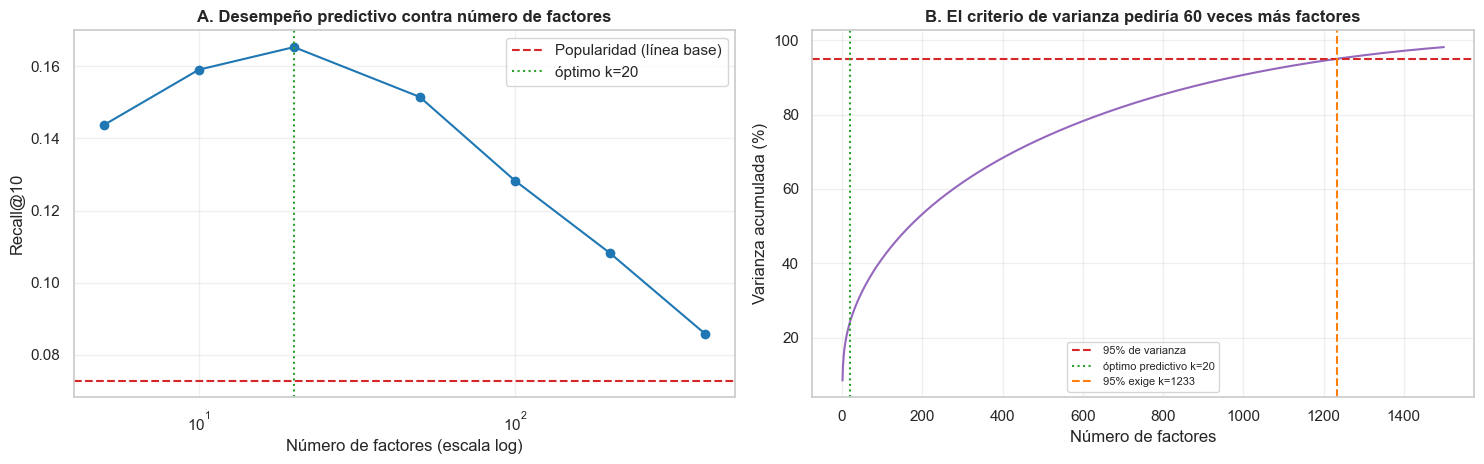

In [34]:
# ==============================================================================
#      CURVA DE DESEMPENO CONTRA NUMERO DE FACTORES
# ==============================================================================
svd_only = eval_svd[eval_svd['motor'].str.startswith('SVD')].copy()
svd_only['k'] = svd_only['motor'].str.split('=').str[-1].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

axes[0].plot(svd_only['k'], svd_only['recall_at_10'], marker='o', color='tab:blue')
axes[0].axhline(base, color='tab:red', ls='--', label='Popularidad (línea base)')
axes[0].axvline(k_optimo, color='tab:green', ls=':', label=f'óptimo k={k_optimo}')
axes[0].set_xscale('log')
axes[0].set_xlabel('Número de factores (escala log)')
axes[0].set_ylabel('Recall@10')
axes[0].set_title('A. Desempeño predictivo contra número de factores',
                  fontsize=12, fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(range(1, 1501), var_acumulada[:1500] * 100, color='tab:purple')
axes[1].axhline(95, color='tab:red', ls='--', label='95% de varianza')
axes[1].axvline(k_optimo, color='tab:green', ls=':', label=f'óptimo predictivo k={k_optimo}')
n_95 = int(np.searchsorted(var_acumulada, 0.95)) + 1
axes[1].axvline(n_95, color='tab:orange', ls='--', label=f'95% exige k={n_95}')
axes[1].set_xlabel('Número de factores')
axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].set_title('B. El criterio de varianza pediría 60 veces más factores',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**El criterio predictivo entrega una respuesta clara, y contradice al descriptivo.**

El desempeño óptimo está en **20 factores**, con un Recall@10 de 0,1653 frente a 0,0729 de la línea base de popularidad. Es decir, **la factorización latente recupera 2,3 veces más artistas retenidos que recomendar lo más escuchado**. Es la primera vez en todo el análisis que un motor supera de forma medible a la línea base del Paso 3.

La curva tiene forma de U invertida: sube hasta $k=20$ y luego se degrada de manera sostenida. Con 400 factores el Recall cae a 0,0858, apenas por encima de la popularidad. La explicación es directa: al añadir factores el modelo empieza a reproducir el patrón de ceros del entrenamiento en vez de generalizar, que es sobreajuste en el sentido más literal.

**Esto cuantifica lo anticipado en la sección anterior.** El criterio de varianza explicada habría pedido 1.233 factores, unas 60 veces más de lo óptimo, en una zona donde el motor ya funciona peor que recomendar lo más popular. El criterio que servía para describir rostros habría arruinado el recomendador.

**Una limitación importante de esta evaluación.** Los artistas retenidos provienen de las listas truncadas a 50, así que son artistas que el usuario ya escuchaba mucho. La métrica mide **capacidad de recuperar preferencias conocidas**, no capacidad de descubrimiento. Un motor que sugiriera un artista nuevo y acertado sería penalizado por esta evaluación exactamente igual que uno que se equivoca, que es el sesgo advertido desde el Paso 1. Volveremos sobre esto al comparar motores.

## 5.3 ¿Qué representan los factores latentes?

In [35]:
# ==============================================================================
#        INTERPRETACION DE LOS PRIMEROS FACTORES LATENTES
# ==============================================================================
from scipy.stats import spearmanr

U_f, s_f, Vt_f = svds(A, k=20)
orden_f = np.argsort(-s_f)
U_f, s_f, Vt_f = U_f[:, orden_f], s_f[orden_f], Vt_f[orden_f]

print("="*100)
print("ARTISTAS CON MAYOR CARGA EN CADA UNO DE LOS PRIMEROS FACTORES")
print("="*100)
for f in range(5):
    v = Vt_f[f]
    top = np.argsort(-np.abs(v))[:8]
    etiquetas = [f"{'+' if v[j] > 0 else '-'}{nombre_artista[artistas_idx[j]]}"
                 f"({int(oyentes_por_artista[j])})" for j in top]
    corr = spearmanr(np.abs(v), oyentes_por_artista).statistic
    print(f"\nFactor {f+1}  (sigma = {s_f[f]:.1f}, "
          f"correlacion |carga| vs oyentes = {corr:+.3f})")
    print("   " + ", ".join(etiquetas))
print()
print("="*100)

ARTISTAS CON MAYOR CARGA EN CADA UNO DE LOS PRIMEROS FACTORES

Factor 1  (sigma = 503.1, correlacion |carga| vs oyentes = +0.666)
   +Britney Spears(522), +Lady Gaga(611), +Rihanna(484), +Katy Perry(473), +Christina Aguilera(407), +Beyoncé(397), +Madonna(429), +Avril Lavigne(417)

Factor 2  (sigma = 330.8, correlacion |carga| vs oyentes = +0.693)
   +The Beatles(480), +Radiohead(393), +Muse(400), +Coldplay(369), +The Killers(304), +Arctic Monkeys(248), +Pink Floyd(258), +Placebo(242)

Factor 3  (sigma = 220.5, correlacion |carga| vs oyentes = +0.628)
   -Paramore(399), -Metallica(224), +Radiohead(393), -Linkin Park(280), +Madonna(429), -Iron Maiden(177), +Depeche Mode(282), -Avenged Sevenfold(118)

Factor 4  (sigma = 211.3, correlacion |carga| vs oyentes = +0.609)
   -Paramore(399), +Pink Floyd(258), +Iron Maiden(177), +Led Zeppelin(196), +Metallica(224), +Black Sabbath(126), +AC/DC(180), -The Killers(304)

Factor 5  (sigma = 177.5, correlacion |carga| vs oyentes = +0.601)
   -Depeche 

**Los factores capturan géneros musicales de forma bastante legible.**

- **Factor 1**: Britney Spears, Lady Gaga, Rihanna, Katy Perry, Christina Aguilera, Beyoncé. Es el eje del **pop comercial femenino**, el consumo dominante de la plataforma.
- **Factor 2**: The Beatles, Radiohead, Muse, Coldplay, The Killers, Arctic Monkeys, Pink Floyd. **Rock británico y alternativo**, claramente separado del anterior.
- **Factor 3**: opone con signo contrario a Metallica, Linkin Park, Iron Maiden y Avenged Sevenfold frente a Radiohead, Madonna y Depeche Mode. Es un eje **metal contra pop electrónico**.
- **Factor 4**: separa Pink Floyd, Led Zeppelin, Black Sabbath y AC/DC de Paramore y The Killers. Funciona como un eje **temporal**, rock clásico contra rock contemporáneo.
- **Factor 5**: agrupa Depeche Mode, Duran Duran, Pet Shop Boys y Michael Jackson. **Synth-pop de los ochenta**.

Que los ejes tengan signo es lo que permite leerlos como géneros y no solo como niveles: un usuario puede cargar positivo o negativo en el mismo factor según hacia qué lado del eje se inclina su gusto.

**Pero hay un matiz que conviene no pasar por alto.** Los cinco factores correlacionan con el número de oyentes entre **+0,60 y +0,69**. No estamos ante un primer factor que capture popularidad y unos siguientes que capturen género: **la popularidad impregna todos los factores**, porque en cada uno los artistas con mayor carga son los más escuchados de su nicho. La descomposición separa estilos, pero lo hace dentro del subconjunto popular del catálogo.

In [36]:
# ==============================================================================
#     ¿LA REDUCCION DE DIMENSION RESCATA O BORRA LA COLA LARGA?
# ==============================================================================
raros = oyentes_por_artista <= 2
medios = (oyentes_por_artista > 2) & (oyentes_por_artista <= 50)
populares = oyentes_por_artista > 50

print("="*92)
print("MAGNITUD MEDIA DE LA RECONSTRUCCION SEGUN POPULARIDAD DEL ARTISTA")
print("="*92)
filas = []
for k in [5, 20, 50, 100, 200]:
    U_k, s_k, Vt_k = svds(A, k=k)
    o_k = np.argsort(-s_k)
    R_k = (U_k[:, o_k] * s_k[o_k]) @ Vt_k[o_k]
    filas.append({
        'k': k,
        'raros_<=2_oyentes': np.abs(R_k[:, raros]).mean(),
        'medios_3_a_50': np.abs(R_k[:, medios]).mean(),
        'populares_>50': np.abs(R_k[:, populares]).mean(),
        'razon_popular_sobre_raro': np.abs(R_k[:, populares]).mean() / np.abs(R_k[:, raros]).mean(),
    })

cola_larga = pd.DataFrame(filas)
print(cola_larga.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("="*92)
print(f"Artistas con 2 oyentes o menos: {int(raros.sum()):,} "
      f"({raros.mean()*100:.1f}% del catalogo)")

MAGNITUD MEDIA DE LA RECONSTRUCCION SEGUN POPULARIDAD DEL ARTISTA


  k  raros_<=2_oyentes  medios_3_a_50  populares_>50  razon_popular_sobre_raro
  5             0.0028         0.0286         0.4443                  157.8732
 20             0.0064         0.0468         0.5150                   79.8722
 50             0.0109         0.0633         0.5633                   51.8113
100             0.0158         0.0799         0.6014                   38.0053
200             0.0229         0.1008         0.6082                   26.6149
Artistas con 2 oyentes o menos: 13,018 (73.8% del catalogo)


**La reducción de dimensionalidad no rescata la cola larga: la borra.**

La magnitud media de la reconstrucción para artistas con dos oyentes o menos es de 0,0028 con 5 factores, frente a 0,4443 para los artistas de más de 50 oyentes. Es una diferencia de **158 veces**. Aumentar el número de factores mejora algo la situación, pero incluso con 200 factores la razón sigue siendo de 27 veces.

El motivo es estructural. Los primeros vectores singulares se construyen para explicar la mayor cantidad posible de varianza, y un artista escuchado por dos personas aporta una cantidad de varianza despreciable. Su información queda fuera de las direcciones retenidas y su reconstrucción se aproxima a cero. Al truncar, **los artistas raros no se proyectan a un lugar razonable del espacio latente, simplemente desaparecen de él**.

Esto afecta directamente al objetivo del cliente: los 10.679 artistas con un solo oyente, el 60,57% del catálogo documentado en el Paso 1, son precisamente los que la factorización tiene menos capacidad de recuperar. La técnica que parecía más prometedora para inferir consumo no observado es, para estos artistas, la que menos puede decir.

## 5.4 Recomendaciones para el usuario 8

La reconstrucción $\hat{A} = U_d S_d V_d^{T}$ produce un valor para cada par usuario-artista, incluidos los no observados. Para generar la lista se toma la fila del usuario, se descartan los artistas que ya escucha y se ordena de mayor a menor.

El material del curso propone centrar la matriz por usuario antes de descomponer. Verificamos qué efecto tiene esa decisión en este caso concreto.

In [37]:
# ==============================================================================
#        MOTOR 4: RECOMENDACION POR FACTORIZACION LATENTE (SVD)
# ==============================================================================
def reconstruir_svd(matriz, d, centrar_por_usuario=False):
    if centrar_por_usuario:
        media_usuario = matriz.mean(axis=1, keepdims=True)
        U_d, s_d, Vt_d = svds(matriz - media_usuario, k=d)
        o = np.argsort(-s_d)
        return (U_d[:, o] * s_d[o]) @ Vt_d[o] + media_usuario
    U_d, s_d, Vt_d = svds(matriz, k=d)
    o = np.argsort(-s_d)
    return (U_d[:, o] * s_d[o]) @ Vt_d[o]


R_sin = reconstruir_svd(A, k_optimo, centrar_por_usuario=False)
R_con = reconstruir_svd(A, k_optimo, centrar_por_usuario=True)

media_fila_u8 = A[u8].mean()
print("="*80)
print("EFECTO DEL CENTRADO POR USUARIO")
print("="*80)
print(f"Media de la fila del usuario 8 : {media_fila_u8:.5f}")
print(f"   (se promedia sobre {A.shape[1]:,} artistas, de los cuales solo "
      f"{int(M_bin[u8].sum())} son distintos de cero)")
print(f"Diferencia maxima entre ambas reconstrucciones: {np.abs(R_sin - R_con).max():.4f}")

def top_n_svd(R, user_id, top_n=10):
    u = pos_usuario[user_id]
    score = R[u].copy()
    score[M_log[u] > 0] = -np.inf
    mejores = np.argsort(-score)[:top_n]
    return pd.DataFrame({
        'artist_id': artistas_idx[mejores],
        'artist_name': [nombre_artista[a] for a in artistas_idx[mejores]],
        'score': score[mejores],
        'oyentes': oyentes_por_artista[mejores].astype(int),
        'rank_global': rank_popularidad[mejores],
    }).reset_index(drop=True)

iguales = set(top_n_svd(R_sin, 8)['artist_id']) == set(top_n_svd(R_con, 8)['artist_id'])
print(f"¿Las dos listas del usuario 8 coinciden?: {iguales}")
print("="*80)

recs_u8_svd = top_n_svd(R_sin, 8, top_n=10)
print()
print("="*88)
print(f"RECOMENDACIONES USUARIO 8: SVD CON {k_optimo} FACTORES")
print("="*88)
print(recs_u8_svd.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print("="*88)
print(f"Artistas dentro del Top 100 global: {(recs_u8_svd['rank_global'] <= 100).sum()}/10")
print(f"Mediana de oyentes de la lista    : {recs_u8_svd['oyentes'].median():.0f}")

EFECTO DEL CENTRADO POR USUARIO
Media de la fila del usuario 8 : 0.01771
   (se promedia sobre 17,632 artistas, de los cuales solo 50 son distintos de cero)


Diferencia maxima entre ambas reconstrucciones: 0.2337
¿Las dos listas del usuario 8 coinciden?: True

RECOMENDACIONES USUARIO 8: SVD CON 20 FACTORES
 artist_id      artist_name  score  oyentes  rank_global
       294      Leona Lewis  4.167      160           61
       301      Alicia Keys  3.363      148           70
        55    Kylie Minogue  2.908      298           19
        67          Madonna  2.897      429            6
      1934            Adele  2.736      126           94
       461      Miley Cyrus  2.346      286           20
      1459 Carrie Underwood  2.329       76          201
       701          Shakira  2.304      319           15
       299   Jennifer Lopez  2.140      209           42
       679        Glee Cast  2.056      249           27
Artistas dentro del Top 100 global: 9/10
Mediana de oyentes de la lista    : 229


In [38]:
# ==============================================================================
#       COMPARACION CON LOS MOTORES ANTERIORES Y COBERTURA DE CATALOGO
# ==============================================================================
set_svd = set(recs_u8_svd['artist_name'])

print("="*80)
print("SOLAPAMIENTO DE LA LISTA SVD CON LOS MOTORES ANTERIORES (usuario 8)")
print("="*80)
print(f"SVD vs popularidad simple : {len(set_svd & set(recs_u8_simple['artist_name']))}/10")
print(f"SVD vs popularidad ponder.: {len(set_svd & set(recs_u8_weighted['artist_name']))}/10")
print(f"SVD vs coseno             : {len(set_svd & set(recs_u8_coseno['artist_name']))}/10")
print(f"Artistas que solo aporta el SVD: "
      f"{sorted(set_svd - set(recs_u8_simple['artist_name']) - set(recs_u8_weighted['artist_name']) - set(recs_u8_coseno['artist_name']))}")
print("="*80)

# Cobertura: artistas distintos recomendados al aplicarlo a los 1.892 usuarios
scores_todos = R_sin.copy()
scores_todos[M_log > 0] = -np.inf
cobertura_svd = set()
for u in range(len(usuarios_idx)):
    cobertura_svd.update(np.argsort(-scores_todos[u])[:10].tolist())

print()
print("COBERTURA DE CATALOGO (SVD aplicado a los 1.892 usuarios)")
print(f"  Artistas distintos recomendados: {len(cobertura_svd):,} "
      f"({len(cobertura_svd)/len(artistas_idx)*100:.2f}% del catalogo)")
print(f"  Mediana de oyentes de esos artistas: "
      f"{np.median([oyentes_por_artista[j] for j in cobertura_svd]):.0f}")

resumen_cuatro = pd.DataFrame([
    perfil_popularidad('Popularidad simple', recs_u8_simple['artist_id']),
    perfil_popularidad('Popularidad ponderada', recs_u8_weighted['artist_id']),
    perfil_popularidad('Coseno usuario-usuario', recs_u8_coseno['artist_id']),
    perfil_popularidad(f'SVD ({k_optimo} factores)', recs_u8_svd['artist_id']),
])
print()
print(resumen_cuatro.to_string(index=False, float_format=lambda v: f"{v:.0f}"))

SOLAPAMIENTO DE LA LISTA SVD CON LOS MOTORES ANTERIORES (usuario 8)
SVD vs popularidad simple : 2/10
SVD vs popularidad ponder.: 4/10
SVD vs coseno             : 6/10
Artistas que solo aporta el SVD: ['Adele', 'Alicia Keys', 'Carrie Underwood', 'Leona Lewis']



COBERTURA DE CATALOGO (SVD aplicado a los 1.892 usuarios)
  Artistas distintos recomendados: 354 (2.01% del catalogo)
  Mediana de oyentes de esos artistas: 80

                 motor  en_top100  mediana_oyentes  rank_global_mediano
    Popularidad simple         10              396                   11
 Popularidad ponderada         10              302                   18
Coseno usuario-usuario         10              312                   16
     SVD (20 factores)          9              229                   34


**El centrado por usuario es prácticamente inerte en este caso.** La media de la fila del usuario 8 es de 0,018, porque se promedia sobre 17.632 artistas de los cuales solo 50 son distintos de cero. Restar esa constante desplaza los valores reconstruidos como mucho en 0,23 pero no altera su orden, de modo que **la lista de los diez artistas resulta idéntica** con y sin centrado. No es una decisión equivocada, simplemente no tiene efecto sobre una matriz tan dispersa, a diferencia de lo que ocurriría con una matriz densa de calificaciones donde cada usuario tiene un nivel de exigencia propio.

**La lista del SVD es la más personalizada de las cuatro construidas hasta ahora.** Comparte solo **2 de 10 artistas con la popularidad simple**, frente a los 5 de 10 del coseno, y aporta cuatro nombres que ningún motor anterior había sugerido: Leona Lewis, Alicia Keys, Adele y Carrie Underwood.

También es la menos mainstream. Su mediana de oyentes es de **229 usuarios**, contra 312 del coseno y 396 de la popularidad simple, e incorpora a Carrie Underwood, en el puesto 201 del ranking global, el primer artista fuera del Top 100 que aparece en una lista para el usuario 8 en todo el análisis.

Y sigue siendo coherente con el perfil: Leona Lewis, Alicia Keys, Adele y Jennifer Lopez encajan con el consumo de pop femenino documentado en el Paso 1.

**En cobertura mejora, pero poco.** Aplicado a los 1.892 usuarios recomienda **354 artistas distintos, el 2,01% del catálogo**, frente al 1,63% del coseno. La mediana de oyentes de ese conjunto es de 80, bastante por debajo de lo que alcanzaban los motores anteriores. Es una mejora real, aunque muy lejos de hacer visible el catálogo.

### Cierre del Paso 5

1. **El criterio de varianza explicada no se traslada a este problema.** Alcanzar el 95% exige 1.233 factores de un máximo de 1.892, y el primer factor explica solo el 8,43%. La varianza de esta matriz está dominada por los ceros, y reproducirlos bien es lo contrario de lo que necesita un recomendador.
2. **El criterio correcto es predictivo.** Reteniendo el 20% de los pares observados, el óptimo está en **20 factores**, unas 60 veces menos de lo que pediría el criterio de varianza.
3. **Es el primer motor que supera de forma medible a la línea base.** Recall@10 de 0,1653 contra 0,0729 de la popularidad, es decir 2,3 veces mejor.
4. **Demasiados factores degradan el modelo.** Con 400 factores el desempeño cae casi al nivel de la popularidad, porque el modelo empieza a reproducir el patrón de ceros en lugar de generalizar.
5. **Los factores capturan géneros legibles**: pop comercial femenino, rock británico, metal contra pop electrónico, rock clásico contra contemporáneo, synth-pop ochentero. Pero **los cinco correlacionan entre +0,60 y +0,69 con la popularidad**: separan estilos dentro del subconjunto popular, no en todo el catálogo.
6. **La reducción de dimensión borra la cola larga.** La reconstrucción de artistas con dos oyentes o menos es 158 veces más débil que la de los populares con 5 factores, y aún 27 veces más débil con 200.
7. **El centrado por usuario que propone el material del curso es inerte aquí**, porque la media de cada fila es de 0,018 sobre una matriz 99,72% vacía. La lista resultante es idéntica con y sin él.
8. **Es la lista más personalizada y menos mainstream hasta ahora**: 2 de 10 coincidencias con popularidad, mediana de 229 oyentes y el primer artista fuera del Top 100 en todo el análisis.
9. **La evaluación tiene un sesgo que hay que declarar**: mide capacidad de recuperar preferencias ya conocidas, no de descubrir. Un acierto de descubrimiento genuino sería penalizado igual que un error.

# Paso 6. Reglas de asociación: análisis de canasta

El cuarto enfoque cambia la unidad de análisis. En lugar de comparar usuarios entre sí o proyectarlos en un espacio latente, trata **la lista de artistas de cada usuario como una canasta de compra** y busca pares que aparezcan juntos con más frecuencia de la esperable por azar.

**Qué aporta una regla que la similitud de coseno no aporta.** Ambas técnicas explotan la co-ocurrencia, pero la resumen de forma distinta y esa diferencia importa.

El coseno mide parecido **entre perfiles completos**: dos usuarios son similares si el conjunto de lo que escuchan se solapa. La recomendación que produce es difusa, en el sentido de que un artista aparece porque muchos usuarios parecidos lo escuchan, sin que se pueda señalar qué parte del perfil lo motivó.

Una regla de asociación es **direccional y local**: dice que quien escucha a $X$ tiende a escuchar también a $Y$, con una fuerza medible, y no exige que los usuarios se parezcan en todo lo demás. Dos consecuencias prácticas se derivan de esto. Primero, permite descubrir vínculos entre nichos que el coseno diluye, porque no necesita que los perfiles coincidan globalmente. Segundo, y más importante para el producto, **la recomendación viene con una explicación concreta**: se le puede decir al usuario "porque escuchas a Cher", que es algo que ningún motor anterior podía ofrecer.

## 6.1 Elección de hiperparámetros a partir de las estadísticas del Paso 1

El soporte mínimo no es un detalle técnico: **define qué artistas pueden llegar a aparecer en alguna regla**. Un artista cuyo soporte no alcance el umbral queda descartado en la primera etapa del algoritmo y, por el principio Apriori, todos los pares que lo contienen quedan descartados con él.

Las estadísticas del Paso 1 dan la escala del problema. La mediana de oyentes por artista es de **1 usuario**, el percentil 75 es de 3 y el percentil 90 es de 8. Con 1.892 usuarios como transacciones, cualquier umbral razonable deja fuera a la mayor parte del catálogo.

In [39]:
# ==============================================================================
#     EFECTO DEL SOPORTE MINIMO SOBRE EL CATALOGO ELEGIBLE
# ==============================================================================
n_transacciones = len(usuarios_idx)          # cada usuario es una canasta
soporte_item = M_bin.sum(axis=0) / n_transacciones

print("="*94)
print("DISTRIBUCION DE OYENTES POR ARTISTA (base para elegir el soporte minimo)")
print("="*94)
serie_oyentes = pd.Series(oyentes_por_artista)
print(f"  mediana {serie_oyentes.median():.0f} | p75 {serie_oyentes.quantile(.75):.0f} | "
      f"p90 {serie_oyentes.quantile(.90):.0f} | p99 {serie_oyentes.quantile(.99):.0f} | "
      f"maximo {serie_oyentes.max():.0f}")
print()
print("Artistas elegibles segun el umbral de soporte:")
filas = []
for s in [0.002, 0.005, 0.01, 0.02, 0.03, 0.05, 0.10]:
    n_elegibles = int((soporte_item >= s).sum())
    filas.append({
        'soporte_min': s,
        'oyentes_minimos': round(s * n_transacciones, 1),
        'artistas_elegibles': n_elegibles,
        'pct_catalogo': n_elegibles / len(artistas_idx) * 100,
        'pares_a_evaluar': n_elegibles * (n_elegibles - 1) // 2,
    })
umbrales = pd.DataFrame(filas)
print(umbrales.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print("="*94)

DISTRIBUCION DE OYENTES POR ARTISTA (base para elegir el soporte minimo)
  mediana 1 | p75 3 | p90 8 | p99 81 | maximo 611

Artistas elegibles segun el umbral de soporte:
 soporte_min  oyentes_minimos  artistas_elegibles  pct_catalogo  pares_a_evaluar
       0.002            3.800                3521        19.969          6196960
       0.005            9.500                1530         8.677          1169685
       0.010           18.900                 838         4.753           350703
       0.020           37.800                 432         2.450            93096
       0.030           56.800                 282         1.599            39621
       0.050           94.600                 135         0.766             9045
       0.100          189.200                  47         0.267             1081


**El soporte mínimo es un recorte del catálogo, y uno muy severo.**

Con un soporte de 0,01, que equivale a exigir 19 oyentes, solo **838 artistas quedan elegibles: el 4,75% del catálogo**. Subir a 0,05 lo reduce a 135 artistas, el 0,77%. Y bajarlo a 0,002 solo llega al 19,97%, a costa de multiplicar por 18 el número de pares a evaluar.

Esto responde de forma directa a la pregunta de la guía sobre qué le ocurre a la cola del catálogo cuando sube el umbral: **desaparece por completo, y no de forma gradual sino desde el primer escalón**. Los 10.679 artistas con un solo oyente tienen soporte 0,00053, muy por debajo de cualquier umbral operable. Ningún ajuste de hiperparámetros los rescata, porque el principio Apriori los elimina antes de generar el primer par.

**Elegimos un soporte mínimo de 0,01.** Es un compromiso: mantiene 838 artistas elegibles, que es cuatro veces más de lo que cualquier motor anterior llegó a recomendar en la práctica, y deja 350.703 pares por evaluar, un volumen perfectamente tratable. Limitamos además las reglas a dos elementos, como indica la guía, lo que mantiene el costo acotado y produce reglas directamente interpretables por el equipo de producto.

## 6.2 Implementación del algoritmo

Las librerías habituales para reglas de asociación (`apyori`, `mlxtend`, `efficient-apriori`) no están disponibles en el entorno. Como en el módulo anterior con `scikit-learn-extra`, implementamos el algoritmo directamente: para reglas de dos elementos es corto, evita una dependencia frágil y deja visible el principio Apriori.

El procedimiento sigue las dos etapas del material del curso:

1. **Conjuntos frecuentes de tamaño 1**: se calcula el soporte de cada artista y se descartan los que no alcanzan el umbral.
2. **Conjuntos frecuentes de tamaño 2**: se evalúan únicamente los pares formados por artistas que sobrevivieron a la etapa anterior. Esta restricción **es** el principio Apriori, ya que ningún par que contenga un artista infrecuente puede ser frecuente.
3. **Reglas**: de cada par frecuente $\{X, Y\}$ se derivan las dos reglas dirigidas $X \Rightarrow Y$ e $Y \Rightarrow X$, con sus métricas.

In [40]:
# ==============================================================================
#           APRIORI PARA REGLAS DE DOS ELEMENTOS
# ==============================================================================
SOPORTE_MIN = 0.01

def apriori_pares(matriz_binaria, soporte_min):
    """Genera reglas de asociacion de dos elementos siguiendo el principio Apriori."""
    n = matriz_binaria.shape[0]
    soporte_1 = matriz_binaria.sum(axis=0) / n

    # Etapa 1: conjuntos frecuentes de tamano 1
    frecuentes = np.where(soporte_1 >= soporte_min)[0]

    # Etapa 2: solo pares entre items frecuentes (principio Apriori)
    sub = matriz_binaria[:, frecuentes]
    soporte_2 = (sub.T @ sub) / n
    np.fill_diagonal(soporte_2, 0.0)
    ii, jj = np.where(np.triu(soporte_2 >= soporte_min, 1))

    # Etapa 3: reglas dirigidas con sus metricas
    registros = []
    for a, b in zip(ii, jj):
        s = soporte_2[a, b]
        for x, y in ((a, b), (b, a)):
            sx, sy = soporte_1[frecuentes[x]], soporte_1[frecuentes[y]]
            confianza = s / sx
            registros.append({
                'x': frecuentes[x], 'y': frecuentes[y],
                'soporte': s, 'confianza': confianza,
                'lift': confianza / sy,
                'apalancamiento': s - sx * sy,
                'conviccion': (1 - sy) / (1 - confianza) if confianza < 1 else np.inf,
            })
    return pd.DataFrame(registros), frecuentes


reglas, items_frecuentes = apriori_pares(M_bin, SOPORTE_MIN)

print("="*80)
print(f"APRIORI CON SOPORTE MINIMO {SOPORTE_MIN}")
print("="*80)
print(f"Etapa 1 - artistas frecuentes : {len(items_frecuentes):,} de {len(artistas_idx):,}")
print(f"Etapa 2 - pares evaluados     : {len(items_frecuentes)*(len(items_frecuentes)-1)//2:,}")
print(f"Etapa 2 - pares frecuentes    : {len(reglas)//2:,}")
print(f"Etapa 3 - reglas dirigidas    : {len(reglas):,}")
print()
print("Reglas que superan cada umbral:")
for c in [0.3, 0.5, 0.8]:
    print(f"  confianza >= {c}: {int((reglas.confianza >= c).sum()):,}")
for l in [2, 3, 5, 10]:
    print(f"  lift >= {l}: {int((reglas.lift >= l).sum()):,}")
print("="*80)

APRIORI CON SOPORTE MINIMO 0.01
Etapa 1 - artistas frecuentes : 838 de 17,632
Etapa 2 - pares evaluados     : 350,703
Etapa 2 - pares frecuentes    : 8,379
Etapa 3 - reglas dirigidas    : 16,758

Reglas que superan cada umbral:
  confianza >= 0.3: 5,970
  confianza >= 0.5: 2,617
  confianza >= 0.8: 459
  lift >= 2: 12,020
  lift >= 3: 7,286
  lift >= 5: 2,202
  lift >= 10: 390


In [41]:
# ==============================================================================
#        LAS REGLAS MAS FUERTES SEGUN CADA METRICA
# ==============================================================================
def mostrar_reglas(df, criterio, n=6):
    print(f"\nTOP {n} REGLAS POR {criterio.upper()}")
    print("-"*104)
    for _, r in df.nlargest(n, criterio).iterrows():
        ax, ay = artistas_idx[int(r.x)], artistas_idx[int(r.y)]
        print(f"  {nombre_artista[ax][:24]:24} => {nombre_artista[ay][:24]:24} "
              f"sop={r.soporte:.4f} conf={r.confianza:.3f} lift={r.lift:7.2f} "
              f"oyentes_consec={int(oyentes_por_artista[int(r.y)]):4}")

print("="*104)
print("CONFIANZA Y LIFT NO ORDENAN LAS MISMAS REGLAS")
print("="*104)
mostrar_reglas(reglas, 'confianza')
mostrar_reglas(reglas, 'lift')
print("-"*104)
print(f"\nCorrelacion de Spearman entre confianza y lift: "
      f"{spearmanr(reglas.confianza, reglas.lift).statistic:+.3f}")
print(f"Oyentes medianos del consecuente en el top 100 por confianza: "
      f"{np.median([oyentes_por_artista[int(v)] for v in reglas.nlargest(100,'confianza').y]):.0f}")
print(f"Oyentes medianos del consecuente en el top 100 por lift      : "
      f"{np.median([oyentes_por_artista[int(v)] for v in reglas.nlargest(100,'lift').y]):.0f}")

CONFIANZA Y LIFT NO ORDENAN LAS MISMAS REGLAS

TOP 6 REGLAS POR CONFIANZA
--------------------------------------------------------------------------------------------------------
  Martin L. Gore           => Depeche Mode             sop=0.0222 conf=1.000 lift=   6.71 oyentes_consec= 282
  Dave Gahan               => Depeche Mode             sop=0.0307 conf=1.000 lift=   6.71 oyentes_consec= 282
  George Harrison          => The Beatles              sop=0.0185 conf=1.000 lift=   3.94 oyentes_consec= 480
  Kat DeLuna               => Rihanna                  sop=0.0227 conf=1.000 lift=   3.91 oyentes_consec= 484
  Kelly Rowland            => Rihanna                  sop=0.0328 conf=1.000 lift=   3.91 oyentes_consec= 484
  Girlicious               => Rihanna                  sop=0.0222 conf=1.000 lift=   3.91 oyentes_consec= 484

TOP 6 REGLAS POR LIFT
--------------------------------------------------------------------------------------------------------
  安室奈美恵                    => 倖田來

**Confianza y lift no dicen lo mismo, y para "Descubre" la diferencia es decisiva.**

Las reglas de mayor confianza son casi tautológicas. *Martin L. Gore* $\Rightarrow$ *Depeche Mode* y *Dave Gahan* $\Rightarrow$ *Depeche Mode* tienen confianza 1,000: **ambos son integrantes de Depeche Mode**. Lo mismo ocurre con *George Harrison* $\Rightarrow$ *The Beatles*. Son reglas perfectamente correctas y completamente inútiles para un módulo de descubrimiento: quien escucha el proyecto solista de Dave Gahan evidentemente ya conoce a Depeche Mode.

La razón es estructural. La confianza es $P(Y\mid X)$, y ese valor es alto tanto cuando existe una asociación genuina como cuando **$Y$ es simplemente muy popular**. Un artista escuchado por el 30% de la base tendrá confianza alta como consecuente de casi cualquier regla.

El lift corrige exactamente eso al dividir por $P(Y)$, de modo que mide cuánto más probable es $Y$ dado $X$ **respecto a su probabilidad de base**. Sus reglas principales son asociaciones fuertes dentro de comunidades de nicho, con lift entre 33 y 48 entre artistas japonesas, valores que indican una co-escucha entre 33 y 48 veces superior a la esperable por azar.

La consecuencia práctica se ve en el consecuente: en las 100 reglas de mayor confianza el artista recomendado tiene una **mediana de 484 oyentes**, mientras que en las 100 de mayor lift la mediana es de **42**. Una diferencia de más de diez veces. **Ordenar por confianza reproduce el sesgo de popularidad; ordenar por lift lo evita.**

Las dos métricas no son independientes, su correlación de Spearman es de +0,405, pero esa asociación moderada basta para que los extremos de cada ranking sean conjuntos de reglas casi disjuntos.

## 6.3 Recomendaciones para el usuario 8

Para generar la lista se buscan las reglas cuyo antecedente esté entre los artistas que el usuario escucha y cuyo consecuente no lo esté. Cada artista candidato se puntúa con la regla más fuerte que lo propone, y esa misma regla queda disponible como explicación.

In [42]:
# ==============================================================================
#        MOTOR 5: RECOMENDACION POR REGLAS DE ASOCIACION
# ==============================================================================
# Matrices de lift y confianza indexadas por posicion dentro de items_frecuentes
pos_en_frecuentes = {a: i for i, a in enumerate(items_frecuentes)}
n_f = len(items_frecuentes)
L_lift = np.zeros((n_f, n_f), dtype=np.float32)
L_conf = np.zeros((n_f, n_f), dtype=np.float32)
for _, r in reglas.iterrows():
    L_lift[pos_en_frecuentes[int(r.x)], pos_en_frecuentes[int(r.y)]] = r.lift
    L_conf[pos_en_frecuentes[int(r.x)], pos_en_frecuentes[int(r.y)]] = r.confianza


COLUMNAS_APRIORI = ['artist_id', 'artist_name', 'porque', 'confianza',
                    'lift', 'oyentes', 'rank_global']


def recomendar_apriori(user_id, top_n=10, criterio='lift', confianza_min=0.0):
    u = pos_usuario[user_id]
    escuchados = M_bin[u] > 0

    # Antecedentes disponibles: artistas del usuario que ademas son frecuentes
    antecedentes = [pos_en_frecuentes[a] for a in items_frecuentes if escuchados[a]]
    if not antecedentes:
        return pd.DataFrame(columns=COLUMNAS_APRIORI)

    matriz = L_lift if criterio == 'lift' else L_conf
    valida = L_conf[antecedentes] >= confianza_min
    puntajes = np.where(valida, matriz[antecedentes], 0.0)

    mejor_valor = puntajes.max(axis=0)
    mejor_antecedente = puntajes.argmax(axis=0)

    # Excluir lo ya escuchado y lo que ninguna regla propone
    for i_f, a in enumerate(items_frecuentes):
        if escuchados[a]:
            mejor_valor[i_f] = 0.0
    candidatos = np.argsort(-mejor_valor)[:top_n]
    candidatos = [c for c in candidatos if mejor_valor[c] > 0]

    filas = []
    for c in candidatos:
        a_y = items_frecuentes[c]
        a_x = items_frecuentes[antecedentes[mejor_antecedente[c]]]
        filas.append({
            'artist_id': artistas_idx[a_y],
            'artist_name': nombre_artista[artistas_idx[a_y]],
            'porque': nombre_artista[artistas_idx[a_x]],
            'confianza': L_conf[pos_en_frecuentes[a_x], c],
            'lift': L_lift[pos_en_frecuentes[a_x], c],
            'oyentes': int(oyentes_por_artista[a_y]),
            'rank_global': rank_popularidad[a_y],
        })
    if not filas:                      # ningun candidato propuesto por reglas
        return pd.DataFrame(columns=COLUMNAS_APRIORI)
    return pd.DataFrame(filas).reset_index(drop=True)


n_frec_u8 = int(sum(M_bin[u8][items_frecuentes] > 0))
print(f"Usuario 8: {int(M_bin[u8].sum())} artistas, de los cuales {n_frec_u8} "
      f"son frecuentes y pueden actuar como antecedente")
print()

for crit in ['confianza', 'lift']:
    r = recomendar_apriori(8, top_n=10, criterio=crit)
    print("="*104)
    print(f"RECOMENDACIONES USUARIO 8 ORDENADAS POR {crit.upper()}")
    print("="*104)
    print(r.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
    print(f"En Top 100 global: {(r['rank_global'] <= 100).sum()}/10 | "
          f"mediana de oyentes: {r['oyentes'].median():.0f}")
    print()

Usuario 8: 50 artistas, de los cuales 27 son frecuentes y pueden actuar como antecedente

RECOMENDACIONES USUARIO 8 ORDENADAS POR CONFIANZA
 artist_id     artist_name              porque  confianza  lift  oyentes  rank_global
        67         Madonna                Cher      0.836 3.689      429            6
       466           Ke$ha         Cheryl Cole      0.820 4.287      362           14
       333   Avril Lavigne Natasha Bedingfield      0.728 3.305      417            7
       701         Shakira         Cheryl Cole      0.680 4.031      319           15
       157 Michael Jackson     Whitney Houston      0.667 4.742      266           23
       461     Miley Cyrus        Taylor Swift      0.652 4.312      286           20
        55   Kylie Minogue         Cheryl Cole      0.648 4.117      298           19
       306 Black Eyed Peas  The Pussycat Dolls      0.605 3.766      304           18
       294     Leona Lewis Natasha Bedingfield      0.605 7.153      160           61


In [43]:
# ==============================================================================
#     COMBINAR LIFT CON UNA CONFIANZA MINIMA
# ==============================================================================
print("="*88)
print("EFECTO DE EXIGIR CONFIANZA MINIMA ADEMAS DE ORDENAR POR LIFT (usuario 8)")
print("="*88)
filas = []
for cmin in [0.0, 0.1, 0.2, 0.3]:
    r = recomendar_apriori(8, top_n=10, criterio='lift', confianza_min=cmin)
    filas.append({
        'confianza_min': cmin,
        'n_recomendaciones': len(r),
        'mediana_oyentes': float(r['oyentes'].median()),
        'en_top100': int((r['rank_global'] <= 100).sum()),
        'lift_mediano': float(r['lift'].median()),
        'confianza_mediana': float(r['confianza'].median()),
    })
print(pd.DataFrame(filas).to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print("="*88)

CONFIANZA_MIN = 0.2
recs_u8_apriori = recomendar_apriori(8, top_n=10, criterio='lift',
                                     confianza_min=CONFIANZA_MIN)
print()
print("="*104)
print(f"LISTA FINAL: LIFT CON CONFIANZA MINIMA {CONFIANZA_MIN}")
print("="*104)
print(recs_u8_apriori.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print("="*104)

set_apriori = set(recs_u8_apriori['artist_name'])
print(f"Solapamiento con popularidad simple: {len(set_apriori & set(recs_u8_simple['artist_name']))}/10")
print(f"Solapamiento con coseno            : {len(set_apriori & set(recs_u8_coseno['artist_name']))}/10")
print(f"Solapamiento con SVD               : {len(set_apriori & set(recs_u8_svd['artist_name']))}/10")

EFECTO DE EXIGIR CONFIANZA MINIMA ADEMAS DE ORDENAR POR LIFT (usuario 8)
 confianza_min  n_recomendaciones  mediana_oyentes  en_top100  lift_mediano  confianza_mediana
         0.000                 10           62.000          0         8.164              0.296
         0.100                 10           65.500          1         8.164              0.346
         0.200                 10           76.000          2         7.882              0.370
         0.300                 10           98.000          3         7.382              0.388

LISTA FINAL: LIFT CON CONFIANZA MINIMA 0.2
 artist_id      artist_name              porque  confianza   lift  oyentes  rank_global
       889     Cyndi Lauper                Cher      0.382 12.455       58          272
       906      Girls Aloud       The Saturdays      0.433 12.237       67          243
      1459 Carrie Underwood      Colbie Caillat      0.333  8.298       76          201
       326             JoJo Natasha Bedingfield      0.2

In [44]:
# ==============================================================================
#      COBERTURA Y LIMITES OPERATIVOS DEL MOTOR DE REGLAS
# ==============================================================================
conteo_recs = []
cobertura_apriori = set()
for uid in usuarios_idx:
    r = recomendar_apriori(uid, top_n=10, criterio='lift', confianza_min=CONFIANZA_MIN)
    conteo_recs.append(len(r))
    cobertura_apriori.update(r['artist_id'].tolist())
conteo_recs = np.array(conteo_recs)

n_frecuentes_por_usuario = M_bin[:, items_frecuentes].sum(axis=1)

# Cobertura si se ordenara solo por lift, sin exigir confianza minima
cobertura_solo_lift = set()
for uid in usuarios_idx:
    r = recomendar_apriori(uid, top_n=10, criterio='lift', confianza_min=0.0)
    cobertura_solo_lift.update(r['artist_id'].tolist())

print("="*88)
print("COBERTURA Y LIMITES OPERATIVOS")
print("="*88)
print(f"Artistas distintos recomendados : {len(cobertura_apriori):,} "
      f"({len(cobertura_apriori)/len(artistas_idx)*100:.2f}% del catalogo)")
print(f"Mediana de oyentes de esos artistas: "
      f"{np.median([oyentes_por_artista[pos_artista[a]] for a in cobertura_apriori]):.0f}")
print(f"Cobertura si se ordenara solo por lift (sin confianza minima): "
      f"{len(cobertura_solo_lift):,} artistas "
      f"({len(cobertura_solo_lift)/len(artistas_idx)*100:.2f}%)")
print()
print(f"Usuarios que reciben las 10 recomendaciones: {int((conteo_recs == 10).sum()):,} "
      f"({(conteo_recs == 10).mean()*100:.1f}%)")
print(f"Usuarios que reciben menos de 10           : {int((conteo_recs < 10).sum()):,}")
print(f"Usuarios que no reciben ninguna            : {int((conteo_recs == 0).sum()):,}")
print(f"Mediana de artistas frecuentes por usuario : "
      f"{np.median(n_frecuentes_por_usuario):.0f} de un maximo de 50")
print("="*88)

COBERTURA Y LIMITES OPERATIVOS
Artistas distintos recomendados : 342 (1.94% del catalogo)
Mediana de oyentes de esos artistas: 78
Cobertura si se ordenara solo por lift (sin confianza minima): 426 artistas (2.42%)

Usuarios que reciben las 10 recomendaciones: 1,839 (97.2%)
Usuarios que reciben menos de 10           : 53
Usuarios que no reciben ninguna            : 37
Mediana de artistas frecuentes por usuario : 30 de un maximo de 50


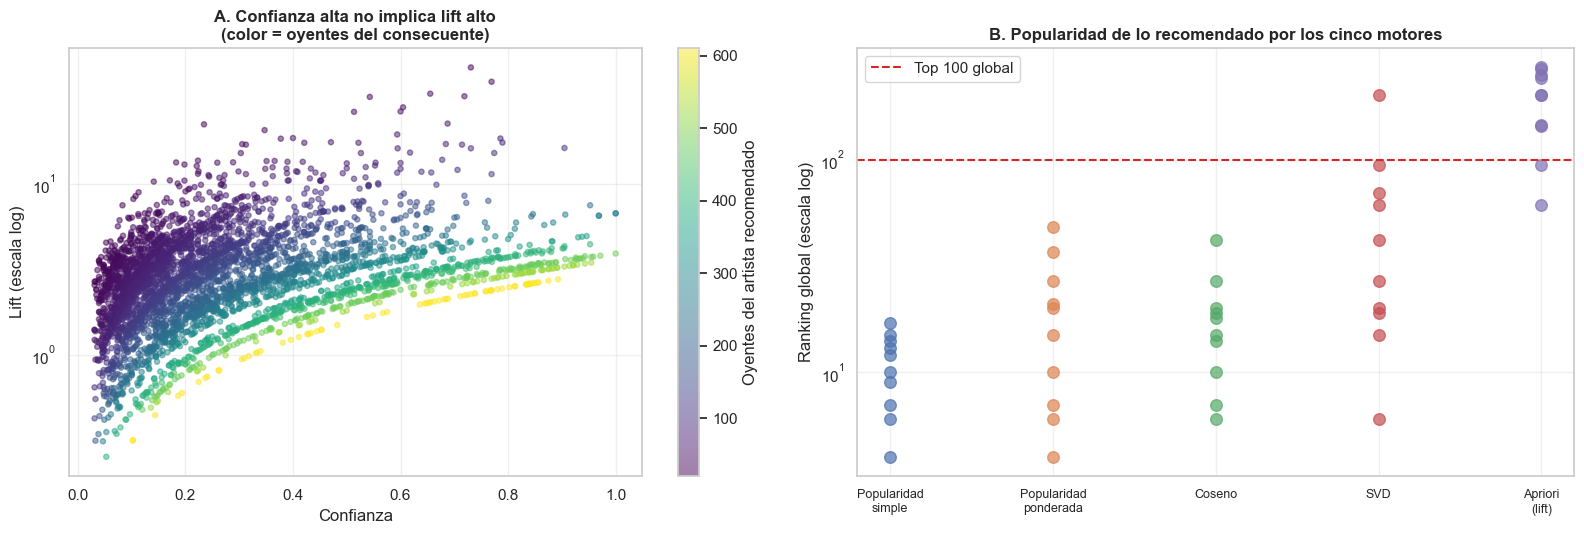

In [45]:
# ==============================================================================
#     VISUALIZACION: CONFIANZA CONTRA LIFT Y PERFIL DE LOS CINCO MOTORES
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

muestra = reglas.sample(min(4000, len(reglas)), random_state=RANDOM_STATE)
oyentes_consec = np.array([oyentes_por_artista[int(v)] for v in muestra.y])
sc = axes[0].scatter(muestra.confianza, muestra.lift, c=oyentes_consec,
                     cmap='viridis', alpha=0.5, s=14)
axes[0].set_yscale('log')
axes[0].set_xlabel('Confianza')
axes[0].set_ylabel('Lift (escala log)')
axes[0].set_title('A. Confianza alta no implica lift alto\n(color = oyentes del consecuente)',
                  fontsize=12, fontweight='bold')
plt.colorbar(sc, ax=axes[0], label='Oyentes del artista recomendado')
axes[0].grid(alpha=0.3)

perfiles = {
    'Popularidad\nsimple': recs_u8_simple['artist_id'],
    'Popularidad\nponderada': recs_u8_weighted['artist_id'],
    'Coseno': recs_u8_coseno['artist_id'],
    'SVD': recs_u8_svd['artist_id'],
    'Apriori\n(lift)': recs_u8_apriori['artist_id'],
}
for i, (nombre, ids) in enumerate(perfiles.items()):
    rangos = [rank_popularidad[pos_artista[a]] for a in ids]
    axes[1].scatter([i] * len(rangos), rangos, alpha=0.7, s=70)
axes[1].axhline(100, color='tab:red', ls='--', label='Top 100 global')
axes[1].set_yscale('log')
axes[1].set_xticks(range(len(perfiles)))
axes[1].set_xticklabels(perfiles.keys(), fontsize=9)
axes[1].set_ylabel('Ranking global (escala log)')
axes[1].set_title('B. Popularidad de lo recomendado por los cinco motores',
                  fontsize=12, fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Es el motor que mejor cumple el objetivo del cliente hasta ahora.**

Ordenada por lift y exigiendo una confianza mínima de 0,2, la lista del usuario 8 contiene a Cyndi Lauper, Girls Aloud, Carrie Underwood, JoJo, Janet Jackson, Jordin Sparks, Jessica Simpson, Leona Lewis, Vanessa Hudgens y Adele. Su mediana de oyentes es de **76 usuarios**, contra 229 del SVD, 312 del coseno y 396 de la popularidad simple, y solo dos de los diez pertenecen al Top 100.

Y **no comparte ningún artista con la popularidad simple ni con el coseno**, apenas 3 de 10 con el SVD. Es genuinamente un motor distinto, no una variación de los anteriores.

Al mismo tiempo la lista sigue siendo plausible: son todas artistas de pop femenino, coherentes con el perfil documentado en el Paso 1. La novedad no se consiguió a costa de la pertinencia aparente.

**La confianza mínima es una salvaguarda necesaria.** Ordenar solo por lift deja pasar reglas de confianza muy baja, asociaciones estadísticamente distintivas pero de poca fuerza absoluta. Exigir 0,2 sube la mediana de oyentes de 62 a 76, un costo pequeño en novedad a cambio de que cada recomendación se apoye en una regla que se cumple al menos una de cada cinco veces.

**Y ofrece algo que ningún otro motor tiene: explicación.** Cada fila trae el antecedente que la generó, de modo que la interfaz puede decir "porque escuchas a Natasha Bedingfield". Es un activo de producto y también un mecanismo de control, porque permite a un analista auditar por qué se recomendó algo.

**Los límites operativos son reales y hay que declararlos.**

La cobertura llega a **342 artistas distintos, el 1,94% del catálogo**, con una mediana de 78 oyentes, muy por debajo de la de los demás motores. Supera al coseno (1,63%) y queda algo por debajo del SVD (2,01%), pero sigue dejando fuera al 98% del catálogo. Conviene notar que la exigencia de confianza mínima cuesta cobertura: ordenando solo por lift el motor alcanzaría 426 artistas, y el filtro que mejora la solidez de cada regla reduce la variedad del conjunto.

Más importante, **el motor no puede atender a todos los usuarios**. Recibe las diez recomendaciones el 97,2% de los usuarios, pero **37 usuarios no reciben ninguna** porque ninguno de sus artistas alcanza el soporte mínimo y por tanto no hay antecedente del que partir. Es el mismo problema de arranque en frío que detectamos en el Paso 4 con los 7 usuarios sin vecinos, agravado: aquí no basta con tener vecinos, hace falta escuchar artistas suficientemente populares.

Y hay una limitación estructural en el propio perfil: de los 50 artistas del usuario 8, solo **27 son frecuentes** y pueden actuar como antecedente. La mediana entre todos los usuarios es de 30 de 50, de modo que **alrededor del 40% de lo que cada persona escucha es invisible para este motor** y no puede generar ninguna recomendación.

### Cierre del Paso 6

1. **El soporte mínimo recorta el catálogo de entrada.** Con 0,01 quedan elegibles 838 artistas, el 4,75% del catálogo; con 0,05 solo 135. Los 10.679 artistas de un solo oyente tienen soporte 0,00053 y ningún ajuste de hiperparámetros los rescata: el principio Apriori los elimina antes de formar el primer par.
2. **Implementamos el algoritmo directamente** porque `apyori`, `mlxtend` y `efficient-apriori` no están disponibles en el entorno. Para reglas de dos elementos es corto y deja visible el principio Apriori.
3. **Confianza y lift no dicen lo mismo.** Las reglas de máxima confianza son tautológicas: *Martin L. Gore* y *Dave Gahan* implican *Depeche Mode* con confianza 1,000 porque **son integrantes de la banda**, igual que *George Harrison* implica *The Beatles*.
4. **La confianza reproduce el sesgo de popularidad** porque $P(Y\mid X)$ es alta cuando $Y$ es popular. El lift lo corrige al dividir por $P(Y)$.
5. **Ordenar por lift produce el mejor resultado de descubrimiento del análisis**: mediana de 76 oyentes contra 229 del SVD y 396 de la popularidad, con solo 2 de 10 artistas en el Top 100.
6. **Conviene exigir además una confianza mínima**, porque el lift solo puede premiar asociaciones distintivas pero débiles. Con 0,2 la mediana sube de 62 a 76 oyentes y cada regla se cumple al menos una de cada cinco veces.
7. **Es el único motor que explica sus recomendaciones**, señalando el artista del perfil que las originó.
8. **No cubre a todos los usuarios**: 37 no reciben ninguna recomendación por no escuchar ningún artista frecuente, y de los 50 artistas de un perfil típico solo unos 30 pueden actuar como antecedente, es decir que el 40% del perfil no genera reglas.

# Paso 7. Comparación, ranking de motores y recomendación

Construimos cinco motores. Este paso los compara bajo criterios explícitos, arma un ranking y traduce esa evidencia en una recomendación para la plataforma.

## 7.1 Con qué criterios comparar

Ningún criterio aislado responde la pregunta del cliente, y varios se contradicen entre sí. Usamos seis, agrupados en dos familias que apuntan a objetivos distintos.

**Qué tan bien acierta el motor:**

- **Recall@10 sobre datos retenidos**: proporción de artistas ocultados que el motor devuelve entre sus diez primeras recomendaciones. Mide capacidad de predecir consumo real.
- **Usuarios atendibles**: cuántos de los 1.892 usuarios reciben efectivamente diez recomendaciones.

**Qué tan bien sirve al módulo "Descubre":**

- **Cobertura de catálogo**: artistas distintos que el motor llega a recomendar al aplicarlo a toda la base. Es la métrica que le importa a los sellos independientes.
- **Popularidad de lo recomendado**: mediana de oyentes y proporción dentro del Top 100 global.
- **Solapamiento entre usuarios**: cuánto se parecen las listas de personas distintas. Un valor alto significa que el motor no personaliza.
- **Explicabilidad**: si el motor puede decir por qué recomienda cada artista. No es cuantificable, pero condiciona lo que la interfaz puede mostrar y lo que un analista puede auditar.

**Una precisión metodológica.** Para que la comparación sea limpia, los cinco motores se reajustan **usando solo el 80% de entrenamiento**: la similitud coseno, la descomposición y las reglas de asociación se recalculan sobre esa partición. De otro modo un motor entrenado con los datos completos tendría ventaja al predecir lo que se le ocultó.

In [46]:
# ==============================================================================
#   COMPARACION DE LOS CINCO MOTORES SOBRE LA MISMA PARTICION RETENIDA
# ==============================================================================
# Todos los motores se reajustan usando SOLO la matriz de entrenamiento
M_bin_train = (A_train > 0).astype(np.float64)

sim_train = cosine_similarity(A_train)
np.fill_diagonal(sim_train, 0.0)
suma_sim_train = sim_train.sum(axis=1)

U_t, s_t, Vt_t = svds(A_train, k=k_optimo)
o_t = np.argsort(-s_t)
R_train = (U_t[:, o_t] * s_t[o_t]) @ Vt_t[o_t]

reglas_train, frec_train = apriori_pares(M_bin_train, SOPORTE_MIN)
pos_frec_train = {a: i for i, a in enumerate(frec_train)}
nft = len(frec_train)
lift_train = np.zeros((nft, nft), dtype=np.float32)
conf_train = np.zeros((nft, nft), dtype=np.float32)
for _, r in reglas_train.iterrows():
    lift_train[pos_frec_train[int(r.x)], pos_frec_train[int(r.y)]] = r.lift
    conf_train[pos_frec_train[int(r.x)], pos_frec_train[int(r.y)]] = r.confianza

pop_simple_train = M_bin_train.sum(axis=0)
pop_pond_train = A_train.sum(axis=0)


def score_apriori_train(u):
    antecedentes = np.where(M_bin_train[u][frec_train] > 0)[0]
    score = np.full(len(artistas_idx), -np.inf)
    if len(antecedentes):
        score[frec_train] = np.where(conf_train[antecedentes] >= CONFIANZA_MIN,
                                     lift_train[antecedentes], 0.0).max(axis=0)
    return score


def score_coseno_train(u):
    if suma_sim_train[u] == 0:
        return np.zeros(len(artistas_idx))
    return (sim_train[u] @ A_train) / suma_sim_train[u]


def score_coseno_soporte_train(u, soporte_min=10):
    """Variante del Paso 4.4: normaliza por los vecinos que si escucharon al artista."""
    s = sim_train[u]
    numerador, denominador = s @ A_train, s @ M_bin_train
    score = np.divide(numerador, denominador,
                      out=np.zeros_like(numerador), where=denominador > 0)
    score[(M_bin_train.T @ (s > 0).astype(np.float64)) < soporte_min] = -np.inf
    return score


motores = {
    'Popularidad simple': lambda u: pop_simple_train,
    'Popularidad ponderada': lambda u: pop_pond_train,
    'Coseno usuario-usuario': score_coseno_train,
    'Coseno + soporte min. 10': score_coseno_soporte_train,
    f'SVD ({k_optimo} factores)': lambda u: R_train[u],
    'Apriori (lift, conf>=0.2)': score_apriori_train,
}

filas = []
for nombre, funcion in motores.items():
    aciertos = total = servidos = 0
    for u, reales in retenidos_por_usuario.items():
        score = np.asarray(funcion(u), dtype=float).copy()
        score[M_bin_train[u] > 0] = -np.inf
        rankeables = int(np.isfinite(score).sum())
        if rankeables >= 10:
            servidos += 1
        orden = np.argsort(-score)
        posicion = np.empty(len(score), dtype=int)
        posicion[orden] = np.arange(len(score))
        for a in reales:
            total += 1
            if posicion[a] < 10:
                aciertos += 1
    filas.append({'motor': nombre, 'recall_at_10': aciertos / total,
                  'usuarios_evaluables': servidos})

precision_motores = pd.DataFrame(filas)
print("="*80)
print("CAPACIDAD PREDICTIVA (20% retenido, motores reajustados solo en train)")
print("="*80)
print(precision_motores.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("="*80)

CAPACIDAD PREDICTIVA (20% retenido, motores reajustados solo en train)
                    motor  recall_at_10  usuarios_evaluables
       Popularidad simple        0.0729                 1877
    Popularidad ponderada        0.0702                 1877
   Coseno usuario-usuario        0.1350                 1877
 Coseno + soporte min. 10        0.0209                 1856
        SVD (20 factores)        0.1653                 1877
Apriori (lift, conf>=0.2)        0.0713                 1854


In [47]:
# ==============================================================================
#      METRICAS DE DESCUBRIMIENTO SOBRE LA BASE COMPLETA
# ==============================================================================
def score_apriori_full(u):
    antecedentes = np.where(M_bin[u][items_frecuentes] > 0)[0]
    score = np.full(len(artistas_idx), -np.inf)
    if len(antecedentes):
        score[items_frecuentes] = np.where(L_conf[antecedentes] >= CONFIANZA_MIN,
                                           L_lift[antecedentes], 0.0).max(axis=0)
    return score


def score_coseno_full(u):
    s = sim_usuarios[u]
    return (s @ M_log) / s.sum() if s.sum() > 0 else np.zeros(len(artistas_idx))


def score_coseno_soporte_full(u, soporte_min=10):
    s = sim_usuarios[u]
    numerador, denominador = s @ M_log, s @ M_bin
    score = np.divide(numerador, denominador,
                      out=np.zeros_like(numerador), where=denominador > 0)
    score[(M_bin.T @ (s > 0).astype(np.float32)) < soporte_min] = -np.inf
    return score


def pertinencia(usuario, recomendados):
    """Jaccard maximo entre cada artista recomendado y el perfil del usuario.

    Mide cuan cerca esta lo recomendado de lo que la persona ya escucha, usando
    solo co-ocurrencia de oyentes: es independiente del motor que lo produjo.
    Valor alto = pertinente pero poco novedoso; valor bajo = novedoso pero
    posiblemente ajeno al gusto.
    """
    perfil = np.where(M_bin[usuario] > 0)[0]
    if len(recomendados) == 0 or len(perfil) == 0:
        return np.nan
    interseccion = M_bin[:, recomendados].T @ M_bin[:, perfil]
    union = (oyentes_por_artista[recomendados][:, None]
             + oyentes_por_artista[perfil][None, :] - interseccion)
    jac = np.divide(interseccion, union, out=np.zeros_like(interseccion), where=union > 0)
    return float(jac.max(axis=1).mean())


motores_full = {
    'Popularidad simple': lambda u: oyentes_por_artista.astype(float),
    'Popularidad ponderada': lambda u: M_log.sum(axis=0).astype(float),
    'Coseno usuario-usuario': score_coseno_full,
    'Coseno + soporte min. 10': score_coseno_soporte_full,
    f'SVD ({k_optimo} factores)': lambda u: R_sin[u],
    'Apriori (lift, conf>=0.2)': score_apriori_full,
}

filas = []
for nombre, funcion in motores_full.items():
    cobertura = set()
    medianas, en_top100, pertinencias = [], [], []
    listas, completos = [], 0
    for u in range(len(usuarios_idx)):
        score = np.asarray(funcion(u), dtype=float).copy()
        score[M_bin[u] > 0] = -np.inf
        top = [j for j in np.argsort(-score)[:10] if np.isfinite(score[j]) and score[j] > 0]
        listas.append(set(top))
        if len(top) == 10:
            completos += 1
        cobertura.update(top)
        if top:
            medianas.append(np.median(oyentes_por_artista[top]))
            en_top100.append((rank_popularidad[top] <= 100).mean())
            pertinencias.append(pertinencia(u, top))

    pares = [(i, j) for i in range(0, 200, 7) for j in range(i + 1, 200, 11)][:400]
    solape = [len(listas[i] & listas[j]) / 10 for i, j in pares if listas[i] and listas[j]]

    filas.append({
        'motor': nombre,
        'cobertura': len(cobertura),
        'pct_catalogo': len(cobertura) / len(artistas_idx) * 100,
        'mediana_oyentes': float(np.median(medianas)),
        'pct_en_top100': float(np.mean(en_top100) * 100),
        'pertinencia': float(np.nanmean(pertinencias)),
        'solape_entre_usuarios_pct': float(np.mean(solape) * 100),
        'usuarios_con_10': completos,
    })

descubrimiento = pd.DataFrame(filas)
print("="*118)
print("METRICAS DE DESCUBRIMIENTO (motores aplicados a los 1.892 usuarios)")
print("="*118)
print(descubrimiento.to_string(index=False, float_format=lambda v: f"{v:.2f}"))
print("="*118)

tabla_final = descubrimiento.merge(precision_motores[['motor', 'recall_at_10']], on='motor')
tabla_final = tabla_final[['motor', 'recall_at_10', 'cobertura', 'pct_catalogo',
                           'mediana_oyentes', 'pct_en_top100', 'pertinencia',
                           'solape_entre_usuarios_pct', 'usuarios_con_10']]
print()
print("TABLA CONSOLIDADA")
print(tabla_final.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print()
print("pertinencia = Jaccard medio entre lo recomendado y el perfil del usuario.")
print("   Alto: cercano a lo que ya escucha. Bajo: novedoso, pero quiza ajeno a su gusto.")

METRICAS DE DESCUBRIMIENTO (motores aplicados a los 1.892 usuarios)
                    motor  cobertura  pct_catalogo  mediana_oyentes  pct_en_top100  pertinencia  solape_entre_usuarios_pct  usuarios_con_10
       Popularidad simple         31          0.18           423.00         100.00         0.25                      65.32             1892
    Popularidad ponderada         30          0.17           423.00         100.00         0.25                      65.82             1892
   Coseno usuario-usuario        288          1.63           293.00          96.56         0.33                      22.59             1885
 Coseno + soporte min. 10        535          3.03            22.50           9.92         0.08                      19.39             1866
        SVD (20 factores)        354          2.01           163.00          69.16         0.26                       5.93             1892
Apriori (lift, conf>=0.2)        342          1.94            61.50           9.99         0

**Lo primero que salta a la vista es el fracaso de la línea base.**

Aplicados a los 1.892 usuarios, los dos motores de popularidad recomiendan **31 y 30 artistas distintos respectivamente: el 0,18% del catálogo**. Con más de 17.000 artistas disponibles, el sistema completo produce una treintena de nombres. El solapamiento entre listas de usuarios distintos es del 65%, y el 100% de lo recomendado pertenece al Top 100 global.

Esto convierte la queja de los sellos independientes en un hecho medido: **si la plataforma sigue recomendando por popularidad, el 99,8% de su catálogo nunca aparecerá en el módulo**.

**El resto de los motores se ordena de forma distinta según qué se mida.**

| Motor | Recall@10 | Cobertura | Mediana oyentes | % en Top 100 | Pertinencia | Solape |
|---|---|---|---|---|---|---|
| Popularidad simple | 0,0729 | 0,18% | 423 | 100,0% | 0,248 | 65,3% |
| Popularidad ponderada | 0,0702 | 0,17% | 423 | 100,0% | 0,247 | 65,8% |
| Coseno | 0,1350 | 1,63% | 293 | 96,6% | 0,328 | 22,6% |
| Coseno + soporte 10 | 0,0209 | **3,03%** | **22,5** | 9,9% | **0,084** | 19,4% |
| **SVD** | **0,1653** | 2,01% | 163 | 69,2% | 0,264 | 6,0% |
| **Apriori** | 0,0713 | 1,94% | 61,5 | **10,0%** | 0,227 | **5,1%** |

Incluimos aquí la variante del coseno con soporte mínimo desarrollada en la sección 4.4, porque allí se demostró que era la perilla capaz de sacarlo del sesgo hacia lo masivo y sería inconsistente compararlo sin ella.

**Esa variante obtiene, en apariencia, los mejores números de descubrimiento de todo el análisis**: la mayor cobertura de catálogo (3,03%) y la menor mediana de oyentes (22,5). Pero las otras dos columnas explican a qué precio.

Su **pertinencia es de 0,084, un tercio de la de cualquier otro motor**. Es decir, recomienda artistas que casi no comparten oyentes con nada de lo que la persona escucha: consigue novedad desconectándose del perfil. Y su recall de 0,0209 es el peor de la tabla, tres veces inferior incluso al de recomendar lo más popular.

Apriori alcanza prácticamente el mismo nivel de evasión del mainstream (10,0% contra 9,9% en el Top 100) **manteniendo una pertinencia de 0,227**, comparable a la de la popularidad y el SVD. Consigue novedad sin soltar el perfil del usuario, que es exactamente lo que el módulo necesita.

Y aparece una contradicción incómoda: **Apriori, el motor que mejor equilibra novedad y pertinencia, es también uno de los que peor puntúa en capacidad predictiva**, con un recall de 0,0713, prácticamente igual al de recomendar lo más popular.

## 7.2 Por qué el motor que mejor descubre parece el que peor acierta

Antes de penalizar a Apriori por su recall conviene entender qué mide esa métrica en este conjunto de datos. Hay dos factores que explican el resultado y ninguno de los dos es que las reglas sean malas.

In [48]:
# ==============================================================================
#     ¿ESTA SESGADA LA METRICA DE RECALL HACIA LOS ARTISTAS POPULARES?
# ==============================================================================
artistas_retenidos = np.array([a for lista in retenidos_por_usuario.values() for a in lista])

print("="*84)
print("PERFIL DE POPULARIDAD DE LOS ARTISTAS QUE LA EVALUACION PIDE ADIVINAR")
print("="*84)
print(f"Mediana de oyentes de los artistas retenidos : "
      f"{np.median(oyentes_por_artista[artistas_retenidos]):.0f}")
print(f"Mediana de oyentes del catalogo completo     : {np.median(oyentes_por_artista):.0f}")
print()
print(f"Retenidos dentro del Top 100 global  : "
      f"{(rank_popularidad[artistas_retenidos] <= 100).mean()*100:5.1f}%  "
      f"(el Top 100 es el {100/len(artistas_idx)*100:.2f}% del catalogo)")
print(f"Retenidos dentro del Top 1000 global : "
      f"{(rank_popularidad[artistas_retenidos] <= 1000).mean()*100:5.1f}%  "
      f"(el Top 1000 es el {1000/len(artistas_idx)*100:.2f}% del catalogo)")
print()
print("TECHO ESTRUCTURAL DE APRIORI")
print(f"Artistas frecuentes en train : {len(frec_train):,} "
      f"({len(frec_train)/len(artistas_idx)*100:.2f}% del catalogo)")
print(f"Artistas retenidos que Apriori puede siquiera rankear: "
      f"{np.isin(artistas_retenidos, frec_train).mean()*100:.1f}%")
print("="*84)

PERFIL DE POPULARIDAD DE LOS ARTISTAS QUE LA EVALUACION PIDE ADIVINAR
Mediana de oyentes de los artistas retenidos : 31
Mediana de oyentes del catalogo completo     : 1

Retenidos dentro del Top 100 global  :  23.8%  (el Top 100 es el 0.57% del catalogo)
Retenidos dentro del Top 1000 global :  61.1%  (el Top 1000 es el 5.67% del catalogo)

TECHO ESTRUCTURAL DE APRIORI
Artistas frecuentes en train : 677 (3.84% del catalogo)
Artistas retenidos que Apriori puede siquiera rankear: 53.6%


**El primer factor: la evaluación premia recomendar lo popular.**

Los artistas que la métrica pide adivinar tienen una mediana de **31 oyentes**, frente a una mediana de **1 oyente** en el catálogo completo. Más revelador todavía: el **61,1% de los artistas retenidos pertenece al Top 1000 global**, cuando ese Top 1000 representa apenas el 5,7% del catálogo.

Esto no es un defecto de nuestro diseño experimental sino una consecuencia directa del truncamiento a 50 artistas advertido desde el Paso 1. Los datos solo registran los artistas más escuchados de cada persona, así que al ocultar una parte estamos ocultando artistas que ya eran favoritos, y esos tienden a ser populares. **Un motor que apunte deliberadamente a la cola del catálogo será penalizado por construcción**, aunque acierte en lo que el módulo "Descubre" pretende lograr.

**El segundo factor: Apriori solo puede opinar sobre una fracción del catálogo.**

Con soporte mínimo 0,01, el motor considera 677 artistas en la partición de entrenamiento, el 3,84% del catálogo. **Solo el 53,6% de los artistas retenidos está siquiera dentro de ese conjunto**: para el 46,4% restante, Apriori no es que se equivoque, es que no tiene ninguna regla que los mencione. Su recall está acotado por diseño, no por la calidad de las reglas.

**La conclusión metodológica es incómoda pero importante: con estos datos no se puede medir bien lo que el cliente quiere.** El recall mide capacidad de recuperar preferencias conocidas, que es casi lo contrario del descubrimiento. Ninguna métrica calculable sobre este histórico distingue una recomendación mala de un descubrimiento acertado que el usuario aún no había hecho. Esa distinción **solo puede zanjarse midiendo el comportamiento real de los usuarios frente al módulo**.

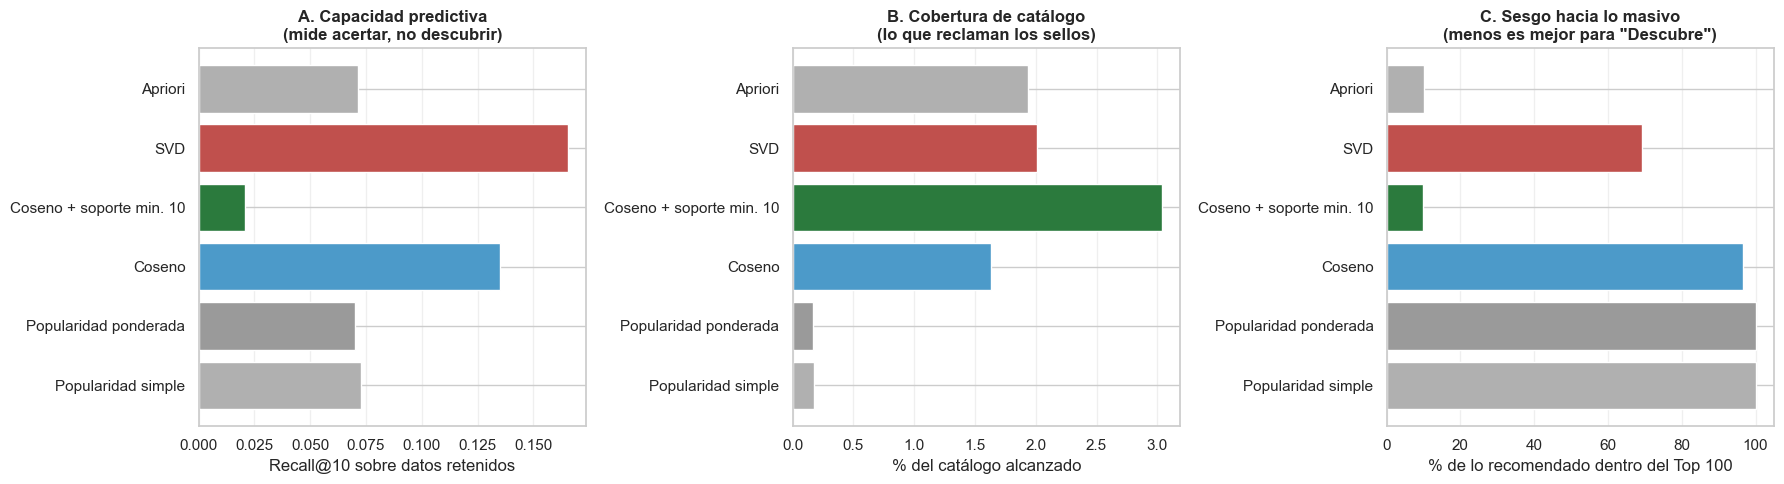

In [49]:
# ==============================================================================
#          VISUALIZACION COMPARATIVA DE LOS CINCO MOTORES
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
etiquetas = [m.replace(' usuario-usuario', '').replace(' (lift, conf>=0.2)', '')
             .replace(f' ({k_optimo} factores)', '') for m in tabla_final['motor']]
colores = ['#b0b0b0', '#9a9a9a', '#4c9ac9', '#2b7a3d', '#c0504d']

axes[0].barh(etiquetas, tabla_final['recall_at_10'], color=colores)
axes[0].set_xlabel('Recall@10 sobre datos retenidos')
axes[0].set_title('A. Capacidad predictiva\n(mide acertar, no descubrir)',
                  fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, axis='x')

axes[1].barh(etiquetas, tabla_final['pct_catalogo'], color=colores)
axes[1].set_xlabel('% del catálogo alcanzado')
axes[1].set_title('B. Cobertura de catálogo\n(lo que reclaman los sellos)',
                  fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')

axes[2].barh(etiquetas, tabla_final['pct_en_top100'], color=colores)
axes[2].set_xlabel('% de lo recomendado dentro del Top 100')
axes[2].set_title('C. Sesgo hacia lo masivo\n(menos es mejor para "Descubre")',
                  fontsize=12, fontweight='bold')
axes[2].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 7.3 Ranking de motores

Ponderamos los criterios según la pregunta del cliente, no según la conveniencia de los algoritmos. El módulo se llama "Descubre" y su propósito declarado es sugerir artistas que el usuario **todavía no escucha** y reducir la concentración del consumo. Por eso damos más peso a cobertura, sesgo de popularidad y personalización que al recall, cuya limitación acabamos de documentar.

| Puesto | Motor | Fortaleza principal | Debilidad principal |
|---|---|---|---|
| **1** | **Apriori (lift, confianza ≥ 0,2)** | Mejor equilibrio novedad-pertinencia: 10,0% en Top 100 con pertinencia 0,227; único motor que explica cada sugerencia | No atiende a 53 usuarios; recall acotado por el soporte mínimo |
| **2** | **SVD (20 factores)** | Mejor recall (0,1653) y buena cobertura (2,01%); atiende a los 1.892 usuarios | El 69,2% de lo que recomienda sigue en el Top 100 |
| 3 | Coseno + soporte mín. 10 | Mayor cobertura de catálogo (3,03%) y menor mediana de oyentes (22,5) | Pertinencia 0,084, un tercio del resto: la novedad se logra desconectando del perfil; peor recall de la tabla |
| 4 | Coseno usuario-usuario | Personaliza más que la popularidad y tiene la pertinencia más alta (0,328) | El 96,6% de lo recomendado está en el Top 100; aporta poco sobre la línea base |
| 5 | Popularidad simple | Trivial de implementar y explicar | 31 artistas de cobertura; no personaliza |
| 6 | Popularidad ponderada | Ninguna sobre la anterior | Igual que la simple, con peor recall |

**Sobre el tercer puesto conviene ser explícito**, porque es donde el ranking podría discutirse. Si el cliente decidiera que lo único que importa es la visibilidad del catálogo, el coseno con soporte mínimo sería la elección correcta: cubre el 3,03% frente al 1,94% de Apriori. Lo situamos por debajo porque su pertinencia de 0,084 sugiere que esa cobertura se consigue recomendando artistas ajenos al gusto del usuario, y una franja de descubrimiento que la gente ignora no hace visible el catálogo, solo lo aparenta. Es una decisión de criterio y queda declarada como tal.

Los dos motores de popularidad quedan al final no por su desempeño predictivo, que es comparable al de Apriori, sino porque **son incompatibles con el objetivo del módulo**: cubren el 0,18% del catálogo y entregan a todos los usuarios prácticamente la misma lista.

El coseno queda tercero porque, pese a personalizar más, sigue recomendando casi exclusivamente artistas del Top 100. Como se documentó en el Paso 4, su sesgo es estructural y no se corrige con hiperparámetros.

## 7.4 Recomendación

**Recomendamos desplegar un esquema híbrido: Apriori ordenado por lift como motor principal del módulo "Descubre", con SVD como motor de respaldo, y hacerlo como piloto medido, no como lanzamiento definitivo.**

**Por qué Apriori como principal.** Es el único motor cuyo resultado se parece a lo que el cliente pidió. Solo el 10,0% de lo que recomienda pertenece al Top 100, contra el 69,2% del SVD y el 96,6% del coseno, y la mediana de oyentes de sus sugerencias es de 61,5 usuarios. Al mismo tiempo sus listas siguen siendo plausibles: para el usuario 8 propone artistas de pop femenino coherentes con su perfil, no rarezas arbitrarias.

**Por qué SVD como respaldo.** Apriori deja sin atender a 53 usuarios, 37 de ellos sin ninguna recomendación, porque no escuchan ningún artista que alcance el soporte mínimo. El SVD atiende a los 1.892 y además tiene la mejor capacidad predictiva medida, así que cubre precisamente el hueco del motor principal.

**Y una razón de producto que no aparece en las métricas.** Apriori es el único que puede decir *por qué*: cada recomendación viene con el artista del perfil que la originó. Para un módulo de descubrimiento eso importa el doble, porque un usuario acepta mejor una sugerencia inesperada si entiende de dónde salió, y porque le da al equipo una vía para auditar recomendaciones extrañas.

**El trade-off que se está aceptando, dicho con claridad.** Elegir Apriori significa renunciar a acertar más, medido con los datos disponibles. Su recall es de 0,0713 frente a 0,1653 del SVD: en la métrica que sabemos calcular, es menos de la mitad de bueno. Aceptamos ese costo porque esa métrica premia recomendar lo que el usuario ya escucharía de todos modos, que es exactamente lo que el módulo no debe hacer. **Estamos cambiando precisión medible por descubrimiento no medible**, y esa es una decisión de negocio que el cliente debe aprobar de forma consciente, no una conclusión que los datos impongan.

## 7.5 Controles y salvaguardas para producción

**1. Reserva para usuarios no atendibles.** 37 usuarios no reciben ninguna recomendación de Apriori y 7 no tienen ningún vecino con similitud positiva. El módulo debe tener una cascada explícita: Apriori, si no alcanza SVD, y si tampoco, una lista de popularidad. Nunca una franja vacía.

**2. Tope de popularidad por lista.** Aunque Apriori tiende a la cola, conviene fijar un máximo de artistas del Top 100 por lista, por ejemplo dos de diez, para que el sesgo no reaparezca si cambian los datos.

**3. Piso de soporte auditable.** El soporte mínimo de 0,01 deja fuera al 95,25% del catálogo. Es una decisión de negocio disfrazada de hiperparámetro y debe estar documentada y revisada, no enterrada en el código.

**4. Registro de la explicación.** Guardar junto a cada recomendación la regla que la generó, con su soporte, confianza y lift. Sin eso no hay forma de auditar una sugerencia inapropiada después del hecho.

**5. Rotación y control de fatiga.** Las reglas son estáticas mientras no se recalculen. Si el módulo muestra siempre lo mismo, reproduce el problema de aburrimiento que motivó el proyecto. Conviene rotar dentro de los candidatos de alto lift y no mostrar siempre los diez primeros.

**6. Revisión editorial previa.** Antes de exponer recomendaciones a usuarios reales, un equipo de contenido debería revisar una muestra. Las reglas de máxima confianza mostraron un caso ilustrativo: recomendar Depeche Mode a quien escucha a Dave Gahan es técnicamente correcto y comercialmente absurdo. Filtros de este tipo, como artistas del mismo proyecto o del mismo integrante, se resuelven con metadatos, no con estadística.

**7. Recálculo periódico y vigilancia de deriva.** Los datos son de 2011. En producción las reglas deben recalcularse con una cadencia definida y monitorearse su estabilidad.

## 7.6 Cómo evaluar objetivamente estas recomendaciones

**Antes del lanzamiento**, con los datos disponibles:

- Las métricas de este cuaderno como línea de partida: recall sobre datos retenidos, cobertura, perfil de popularidad y solapamiento entre usuarios.
- Un **panel de revisión humana**: un grupo de personas del equipo de contenido evalúa listas de una muestra de usuarios y puntúa cada sugerencia como plausible o no. Esto captura lo que el recall no puede, que es si una recomendación novedosa tiene sentido.
- **Pruebas de robustez**: repetir el análisis con otra semilla de partición y con otro soporte mínimo, verificando que el ranking de motores no cambie.

**Después del lanzamiento**, que es donde se resuelve de verdad:

- **Prueba A/B con tres brazos**: popularidad como control, SVD y Apriori. El control es indispensable, porque sin él cualquier cifra de interacción parecerá buena.
- **Qué medir**, en dos niveles:
  - *Interacción inmediata*: tasa de clic sobre la franja, reproducciones iniciadas desde el módulo, y sobre todo **artistas guardados o seguidos**, que indica adopción real y no curiosidad.
  - *Efecto de negocio*: evolución de la concentración del consumo (por ejemplo el índice de Gini sobre reproducciones por artista), número de artistas distintos que reciben al menos una reproducción vía el módulo, proporción de reproducciones que va a sellos independientes, y retención a 30 y 90 días, que es la variable que originó el encargo.
- **Sobre qué datos**: consumo real posterior a la exposición, no el histórico. Y con un horizonte suficiente, porque el descubrimiento se manifiesta en semanas, no en clics inmediatos.
- **Contra qué punto de comparación**: el brazo de popularidad. La pregunta operativa no es si Apriori es bueno en abstracto, sino si mejora la retención y la diversidad **respecto a lo que la plataforma ya hace**.

## 7.7 Limitaciones y decisión solicitada al cliente

**Lo que estos datos sí permiten concluir.** Que la recomendación por popularidad es incompatible con el objetivo del módulo, y esto está medido: cubre el 0,18% del catálogo. Que el coseno no corrige ese problema por razones estructurales. Que existen motores capaces de recomendar artistas de la cola manteniendo coherencia con el perfil del usuario.

**Lo que estos datos no permiten concluir.** Cuál de esos motores producirá mejores resultados de negocio. La métrica disponible está sesgada hacia lo popular, el histórico está truncado a 50 artistas por usuario y **los datos son de 2011**: los artistas concretos que aparecen en estas listas no deben interpretarse como sugerencias para hoy. Lo que se traslada es la elección de motor y sus condiciones, no el contenido.

**Tampoco resuelve la petición central del cliente.** Ningún motor evaluado hace visible el catálogo: el mejor alcanza el 2,01%, y el 60,57% de los artistas con un solo oyente permanece fuera del alcance de cualquier técnica basada solo en co-ocurrencia. Hacer visible esa cola requiere **información que estos datos no contienen**: género, etiquetas, características de audio o similitud de contenido. Es la principal recomendación de inversión que se desprende del análisis.

**La decisión que se solicita.** No aprobar un despliegue definitivo, sino:

1. **Autorizar un piloto A/B de tres brazos** durante un trimestre, con la asignación de tráfico y los umbrales de éxito acordados de antemano.
2. **Fijar con el cliente el umbral de éxito antes de medir**, en particular cuánta caída de interacción inmediata está dispuesto a tolerar a cambio de mayor diversidad. Sin ese acuerdo previo, cualquier resultado podrá narrarse como éxito.
3. **Aprobar la incorporación de metadatos de artista** al roadmap, que es el único camino identificado para atender al 60% del catálogo que hoy ningún motor alcanza.

### Cierre del Paso 7

1. **La popularidad es incompatible con el objetivo del módulo**: aplicada a los 1.892 usuarios recomienda 31 artistas distintos, el 0,18% del catálogo, con un 65% de solapamiento entre usuarios. La queja de los sellos independientes queda confirmada con números.
2. **El coseno personaliza pero no descubre**: el 96,6% de lo que recomienda sigue en el Top 100.
3. **El SVD gana en las métricas de acierto**, con recall 0,1653 y cobertura del 2,01%, y atiende a todos los usuarios.
4. **Apriori gana en las métricas de descubrimiento**, con solo el 10,0% de lo recomendado en el Top 100 y una mediana de 61,5 oyentes, y es el único que explica sus sugerencias.
5. **Su bajo recall no significa que recomiende mal.** La evaluación pide adivinar artistas cuya mediana de oyentes es 31 frente a 1 del catálogo, con el 61,1% dentro del Top 1000, y Apriori solo puede rankear al 53,6% de ellos por su propio soporte mínimo.
6. **Recomendamos Apriori como motor principal con SVD de respaldo**, desplegado como piloto medido y con controles: cascada para usuarios no atendibles, tope de popularidad por lista, registro de la explicación y revisión editorial previa.
7. **El trade-off se acepta de forma explícita**: se renuncia a precisión medible a cambio de descubrimiento no medible, porque la métrica disponible premia recomendar lo que el usuario ya escucharía.
8. **La decisión que se pide al cliente es aprobar un piloto A/B de tres brazos**, fijar los umbrales de éxito antes de medir e incorporar metadatos de artista, único camino identificado para el 60% del catálogo que ningún motor alcanza.

# Anexo. Resumen consolidado de cifras

Todas las cifras que sustentan la presentación ejecutiva, reunidas y recalculadas en un solo lugar. Cada valor de este anexo procede de los cálculos de los pasos anteriores y se vuelve a imprimir aquí para que cualquier dato citado en una diapositiva pueda verificarse sin recorrer el cuaderno entero.

In [50]:
# ==============================================================================
#          RESUMEN DE CIFRAS PARA LA PRESENTACION
# ==============================================================================
sep = "=" * 78

print(sep)
print("1. LA BASE DE DATOS")
print(sep)
print(f"Usuarios                          : {len(usuarios_idx):,}")
print(f"Artistas en el catalogo           : {df_artists['artist_id'].nunique():,}")
print(f"Pares usuario-artista observados  : {len(df_user_artists):,}")
print(f"Densidad de la matriz             : "
      f"{len(df_user_artists)/(len(usuarios_idx)*len(artistas_idx))*100:.3f}%")
print(f"Artistas por usuario (truncado)   : maximo {int(M_bin.sum(axis=1).max())}, "
      f"mediana {int(np.median(M_bin.sum(axis=1)))}")
print(f"Reproducciones por par            : mediana {df_user_artists['plays'].median():,.0f}, "
      f"maximo {df_user_artists['plays'].max():,}")

print()
print(sep)
print("2. LA CONCENTRACION DEL CONSUMO (el problema del cliente)")
print(sep)
un_oyente = int((oyentes_por_artista == 1).sum())
dos_o_menos = int((oyentes_por_artista <= 2).sum())
print(f"Artistas con un solo oyente       : {un_oyente:,} "
      f"({un_oyente/len(artistas_idx)*100:.2f}% del catalogo)")
print(f"Artistas con dos oyentes o menos  : {dos_o_menos:,} "
      f"({dos_o_menos/len(artistas_idx)*100:.2f}% del catalogo)")
print(f"Mediana de oyentes por artista    : {np.median(oyentes_por_artista):.0f}")
print(f"Artista mas escuchado             : "
      f"{nombre_artista[artistas_idx[int(np.argmax(oyentes_por_artista))]]} "
      f"({int(oyentes_por_artista.max())} oyentes)")
print(f"Si solo se recomienda el Top 100  : queda invisible el "
      f"{(1 - 100/len(artistas_idx))*100:.2f}% del catalogo")

print()
print(sep)
print("3. COMPARACION DE LOS CINCO MOTORES")
print(sep)
print(tabla_final.to_string(index=False, float_format=lambda v: f"{v:.2f}"))
print()
print("Lectura: 'recall_at_10' mide acertar consumo conocido; 'pct_en_top100' y")
print("'mediana_oyentes' miden sesgo hacia lo masivo (menos es mejor para Descubre);")
print("'solape_entre_usuarios_pct' mide falta de personalizacion.")

print()
print(sep)
print("4. POR QUE EL RECALL NO DECIDE (sesgo de la evaluacion)")
print(sep)
art_ret = np.array([a for lista in retenidos_por_usuario.values() for a in lista])
print(f"Mediana de oyentes de los artistas retenidos : "
      f"{np.median(oyentes_por_artista[art_ret]):.0f}")
print(f"Mediana de oyentes del catalogo              : "
      f"{np.median(oyentes_por_artista):.0f}")
print(f"Retenidos dentro del Top 1000 global         : "
      f"{(rank_popularidad[art_ret] <= 1000).mean()*100:.1f}% "
      f"(el Top 1000 es el {1000/len(artistas_idx)*100:.2f}% del catalogo)")
print(f"Retenidos que Apriori puede rankear          : "
      f"{np.isin(art_ret, frec_train).mean()*100:.1f}%")

print()
print(sep)
print("5. EL MOTOR RECOMENDADO Y SUS LIMITES")
print(sep)
print(f"Motor principal  : Apriori ordenado por lift, soporte minimo {SOPORTE_MIN}, "
      f"confianza minima {CONFIANZA_MIN}")
print(f"Motor de respaldo: SVD con {k_optimo} factores")
print(f"Cobertura de Apriori        : {len(cobertura_apriori):,} artistas "
      f"({len(cobertura_apriori)/len(artistas_idx)*100:.2f}% del catalogo)")
print(f"Cobertura del SVD           : {len(cobertura_svd):,} artistas "
      f"({len(cobertura_svd)/len(artistas_idx)*100:.2f}% del catalogo)")
print(f"Usuarios sin recomendacion de Apriori : {int((conteo_recs == 0).sum())}")
print(f"Usuarios sin ningun vecino (coseno)   : "
      f"{int((sim_usuarios.sum(axis=1) == 0).sum())}")
print(f"Artistas elegibles para Apriori       : {len(items_frecuentes):,} "
      f"({len(items_frecuentes)/len(artistas_idx)*100:.2f}% del catalogo)")
print(f"Cobertura maxima alcanzada por cualquier motor: "
      f"{tabla_final['pct_catalogo'].max():.2f}% del catalogo")

print()
print(sep)
print("6. EL CASO ILUSTRATIVO: USUARIO 8")
print(sep)
print(f"Artistas que escucha        : {int(M_bin[u8].sum())}")
print(f"Artista favorito            : "
      f"{df_interactions[df_interactions.user_id==8].nlargest(1,'plays')['artist_name'].iloc[0]} "
      f"({df_interactions[df_interactions.user_id==8]['plays'].max():,} reproducciones)")
print(f"Vecinos con similitud > 0   : {int((sim_usuarios[u8] > 0).sum()):,} de "
      f"{len(usuarios_idx)-1:,}")
print(f"Artistas suyos que son frecuentes (Apriori): {n_frec_u8} de "
      f"{int(M_bin[u8].sum())}")
print()
print("Mediana de oyentes de la lista que recibe con cada motor:")
for nombre, recs in [('Popularidad simple', recs_u8_simple), ('Popularidad ponderada', recs_u8_weighted),
                     ('Coseno', recs_u8_coseno), (f'SVD ({k_optimo} factores)', recs_u8_svd),
                     ('Apriori (lift)', recs_u8_apriori)]:
    pos = [pos_artista[a] for a in recs['artist_id']]
    print(f"   {nombre:26} {np.median(oyentes_por_artista[pos]):6.1f} oyentes | "
          f"{int((rank_popularidad[pos] <= 100).sum())}/10 en el Top 100")
print(sep)

1. LA BASE DE DATOS
Usuarios                          : 1,892
Artistas en el catalogo           : 17,632
Pares usuario-artista observados  : 92,834
Densidad de la matriz             : 0.278%
Artistas por usuario (truncado)   : maximo 50, mediana 50
Reproducciones por par            : mediana 260, maximo 352,698

2. LA CONCENTRACION DEL CONSUMO (el problema del cliente)
Artistas con un solo oyente       : 10,679 (60.57% del catalogo)
Artistas con dos oyentes o menos  : 13,018 (73.83% del catalogo)
Mediana de oyentes por artista    : 1
Artista mas escuchado             : Lady Gaga (611 oyentes)
Si solo se recomienda el Top 100  : queda invisible el 99.43% del catalogo

3. COMPARACION DE LOS CINCO MOTORES
                    motor  recall_at_10  cobertura  pct_catalogo  mediana_oyentes  pct_en_top100  pertinencia  solape_entre_usuarios_pct  usuarios_con_10
       Popularidad simple          0.07         31          0.18           423.00         100.00         0.25                      65.

**Resumen del Anexo** 

1. **La base** sitúa el problema y su escala.
2. **La concentración** documenta la queja del cliente con cifras: el 60,57% del catálogo tiene un solo oyente y recomendar por popularidad deja invisible al 99,43%.
3. **La comparación de motores** es la evidencia central del ranking.
4. **El sesgo de la evaluación** justifica por qué el motor con mejor recall no es el recomendado, que es el punto más delicado de defender ante el cliente.
5. **El motor recomendado y sus límites** aporta las cifras de la propuesta y de sus resguardos.
6. **El usuario 8** permite mostrar el efecto de cada motor sobre una persona concreta, que suele comunicar mejor que las medias agregadas.